In [1]:
import pandas as pd
import re

orthogroups = pd.read_csv(
    "/staging/leuven/stg_00171/Mark/OrthoFinder/2026_07_proteomes/OrthoFinder/Results_Aug04/Orthogroups/Orthogroups.tsv",
    sep="\t"
)

genes_of_interest = [
    "OctVul6B029372",  # dlx
    "OctVul6B025891",  # prox1/2
    "OctVul6B013114",  # gcm
    "OctVul6B014263",  # slug
    "OctVul6B005118",  # insm
    "OctVul6B026448",  # tbx2/3
    "OctVul6B031322",  # onecut
    "OctVul6B001883",  # gif
    "GFAP",
    "OctVul6B013567",  # nkx21/24
    "OctVul6B028298",  # nkx61/62/63
    "OctVul6B002384",  # tfdp
    "OctVul6B022995",  # runx
    "FBgn0003870",     # tramtrack isoform A
    "FBgn0011701",     # repo
]

matches = []

species_columns = orthogroups.columns.drop("Orthogroup")

for gene in genes_of_interest:
    gene_pattern = re.escape(gene)

    for species in species_columns:
        mask = (
            orthogroups[species]
            .astype("string")
            .str.contains(gene_pattern, regex=True, na=False)
        )

        matched_rows = orthogroups.loc[
            mask,
            ["Orthogroup", species]
        ]

        for _, row in matched_rows.iterrows():
            matches.append({
                "gene": gene,
                "orthogroup": row["Orthogroup"],
                "species_column": species,
                "matched_entry": row[species]
            })

matches_df = pd.DataFrame(matches)

In [2]:
matches_df

,gene,orthogroup,species_column,matched_entry
0,OctVul6B029372,OG0000402,Ovul_MP_TD,"G50117.14_OctVul6B029372, OctVul6B003880T1.p1_..."
1,OctVul6B025891,OG0004005,Ovul_MP_TD,"OctVul6B000692T1.p1_OctVul6B000692, OctVul6B02..."
2,OctVul6B013114,OG0003041,Ovul_MP_TD,OctVul6B013114T1.p1_OctVul6B013114
3,OctVul6B014263,OG0002113,Ovul_MP_TD,"G1887.1_OctVul6B007446, GE_FLAMseq_Quantseq~Oc..."
4,OctVul6B005118,OG0002275,Ovul_MP_TD,OctVul6B005118T1.p1_OctVul6B005118
5,OctVul6B026448,OG0000200,Ovul_MP_TD,"OctVul6B007760T1.p1_OctVul6B007760, OctVul6B00..."
6,OctVul6B031322,OG0001919,Ovul_MP_TD,OctVul6B031322T1.p1_OctVul6B031322
7,OctVul6B001883,OG0000395,Ovul_MP_TD,"G37543.116_OctVul6B018755, G58501.11_OctVul6B0..."
8,GFAP,OG0000383,Hsap,sp|A6NCN2|KR87P_HUMAN Putative keratin-87 prot...
9,OctVul6B013567,OG0000376,Ovul_MP_TD,"G12784.2_OctVul6B000276, OctVul6B013567T2.p1_O..."


In [3]:
gene_orthogroups = (
    matches_df[
        ["gene", "orthogroup", "species_column"]
    ]
    .drop_duplicates()
    .sort_values(["species_column", "gene"])
    .reset_index(drop=True)
)

gene_orthogroups

,gene,orthogroup,species_column
0,FBgn0003870,OG0000551,Dmel
1,FBgn0011701,OG0000239,Dmel
2,GFAP,OG0000383,Hsap
3,OctVul6B001883,OG0000395,Ovul_MP_TD
4,OctVul6B002384,OG0003211,Ovul_MP_TD
5,OctVul6B005118,OG0002275,Ovul_MP_TD
6,OctVul6B013114,OG0003041,Ovul_MP_TD
7,OctVul6B013567,OG0000376,Ovul_MP_TD
8,OctVul6B014263,OG0002113,Ovul_MP_TD
9,OctVul6B022995,OG0001689,Ovul_MP_TD


In [4]:
def extract_matching_entries(cell, gene):
    if pd.isna(cell):
        return []

    entries = [entry.strip() for entry in str(cell).split(",")]

    return [
        entry
        for entry in entries
        if gene in entry
    ]

matches = []

for gene in genes_of_interest:
    for _, row in orthogroups.iterrows():

        for species in orthogroups.columns.drop("Orthogroup"):
            matching_entries = extract_matching_entries(
                row[species],
                gene
            )

            for entry in matching_entries:
                matches.append({
                    "gene": gene,
                    "orthogroup": row["Orthogroup"],
                    "species_column": species,
                    "matched_entry": entry
                })

matches_df = pd.DataFrame(matches)

In [5]:
matches_df

,gene,orthogroup,species_column,matched_entry
0,OctVul6B029372,OG0000402,Ovul_MP_TD,G50117.14_OctVul6B029372
1,OctVul6B025891,OG0004005,Ovul_MP_TD,OctVul6B025891T1.p1_OctVul6B025891
2,OctVul6B013114,OG0003041,Ovul_MP_TD,OctVul6B013114T1.p1_OctVul6B013114
3,OctVul6B014263,OG0002113,Ovul_MP_TD,GE_FLAMseq_Quantseq~OctVul6B014263T1.p1_OctVul...
4,OctVul6B005118,OG0002275,Ovul_MP_TD,OctVul6B005118T1.p1_OctVul6B005118
5,OctVul6B026448,OG0000200,Ovul_MP_TD,OctVul6B026448T1.p1_OctVul6B026448
6,OctVul6B031322,OG0001919,Ovul_MP_TD,OctVul6B031322T1.p1_OctVul6B031322
7,OctVul6B001883,OG0000395,Ovul_MP_TD,OctVul6B001883T1.p1_OctVul6B001883
8,GFAP,OG0000383,Hsap,sp|P14136|GFAP_HUMAN Glial fibrillary acidic p...
9,OctVul6B013567,OG0000376,Ovul_MP_TD,OctVul6B013567T2.p1_OctVul6B013567


In [6]:
found_genes = set(matches_df["gene"])

not_found = [
    gene
    for gene in genes_of_interest
    if gene not in found_genes
]

print("Genes not found:")
print(not_found)

Genes not found:
[]


# create phylogenetic trees

Resolved_Gene_trees/ ... these are the trees OrthoFinder has resolved using its species tree aware analysis

In [7]:
# add tree paths to the dataframe

from pathlib import Path

results_dir = Path(
    "/staging/leuven/stg_00171/Mark/OrthoFinder/2026_07_proteomes/OrthoFinder/Results_Aug04"
)

tree_dir = results_dir / "Resolved_Gene_Trees"

matches_df["tree_file"] = matches_df["orthogroup"].apply(
    lambda og: tree_dir / f"{og}_tree.txt"
)

matches_df["tree_exists"] = matches_df["tree_file"].apply(
    lambda path: path.exists()
)

matches_df[
    ["gene", "orthogroup", "tree_file", "tree_exists"]
]

,gene,orthogroup,tree_file,tree_exists
0,OctVul6B029372,OG0000402,/staging/leuven/stg_00171/Mark/OrthoFinder/202...,True
1,OctVul6B025891,OG0004005,/staging/leuven/stg_00171/Mark/OrthoFinder/202...,True
2,OctVul6B013114,OG0003041,/staging/leuven/stg_00171/Mark/OrthoFinder/202...,True
3,OctVul6B014263,OG0002113,/staging/leuven/stg_00171/Mark/OrthoFinder/202...,True
4,OctVul6B005118,OG0002275,/staging/leuven/stg_00171/Mark/OrthoFinder/202...,True
5,OctVul6B026448,OG0000200,/staging/leuven/stg_00171/Mark/OrthoFinder/202...,True
6,OctVul6B031322,OG0001919,/staging/leuven/stg_00171/Mark/OrthoFinder/202...,True
7,OctVul6B001883,OG0000395,/staging/leuven/stg_00171/Mark/OrthoFinder/202...,True
8,GFAP,OG0000383,/staging/leuven/stg_00171/Mark/OrthoFinder/202...,True
9,OctVul6B013567,OG0000376,/staging/leuven/stg_00171/Mark/OrthoFinder/202...,True


In [9]:
for _, row in matches_df.drop_duplicates("orthogroup").iterrows():
    source = Path(row["tree_file"])

    if not source.exists():
        continue

    gene_name = gene_names.get(row["gene"], row["gene"])
    destination = (
        selected_tree_dir /
        f"{gene_name}_{row['orthogroup']}_tree.txt"
    )

    shutil.copy2(source, destination)

NameError: name 'selected_tree_dir' is not defined

In [15]:
# copy trees that I need

import shutil

selected_tree_dir = Path("selected_orthofinder_trees")
selected_tree_dir.mkdir(exist_ok=True)

selected_trees = (
    matches_df[
        ["orthogroup", "tree_file"]
    ]
    .drop_duplicates()
)

for _, row in selected_trees.iterrows():
    source = Path(row["tree_file"])

    if source.exists():
        destination = selected_tree_dir / source.name
        shutil.copy2(source, destination)
    else:
        print(f"Missing: {source}")

In [16]:
selected_trees

,orthogroup,tree_file
0,OG0002000,/staging/leuven/stg_00171/Mark/OrthoFinder/202...
1,OG0005148,/staging/leuven/stg_00171/Mark/OrthoFinder/202...
2,OG0004164,/staging/leuven/stg_00171/Mark/OrthoFinder/202...
3,OG0002706,/staging/leuven/stg_00171/Mark/OrthoFinder/202...
4,OG0003237,/staging/leuven/stg_00171/Mark/OrthoFinder/202...
5,OG0000163,/staging/leuven/stg_00171/Mark/OrthoFinder/202...
6,OG0000704,/staging/leuven/stg_00171/Mark/OrthoFinder/202...
7,OG0000496,/staging/leuven/stg_00171/Mark/OrthoFinder/202...
8,OG0000537,/staging/leuven/stg_00171/Mark/OrthoFinder/202...
9,OG0000508,/staging/leuven/stg_00171/Mark/OrthoFinder/202...


# plotting in python

In [10]:
matches_df

,gene,orthogroup,species_column,matched_entry,tree_file,tree_exists
0,OctVul6B029372,OG0000402,Ovul_MP_TD,G50117.14_OctVul6B029372,/staging/leuven/stg_00171/Mark/OrthoFinder/202...,True
1,OctVul6B025891,OG0004005,Ovul_MP_TD,OctVul6B025891T1.p1_OctVul6B025891,/staging/leuven/stg_00171/Mark/OrthoFinder/202...,True
2,OctVul6B013114,OG0003041,Ovul_MP_TD,OctVul6B013114T1.p1_OctVul6B013114,/staging/leuven/stg_00171/Mark/OrthoFinder/202...,True
3,OctVul6B014263,OG0002113,Ovul_MP_TD,GE_FLAMseq_Quantseq~OctVul6B014263T1.p1_OctVul...,/staging/leuven/stg_00171/Mark/OrthoFinder/202...,True
4,OctVul6B005118,OG0002275,Ovul_MP_TD,OctVul6B005118T1.p1_OctVul6B005118,/staging/leuven/stg_00171/Mark/OrthoFinder/202...,True
5,OctVul6B026448,OG0000200,Ovul_MP_TD,OctVul6B026448T1.p1_OctVul6B026448,/staging/leuven/stg_00171/Mark/OrthoFinder/202...,True
6,OctVul6B031322,OG0001919,Ovul_MP_TD,OctVul6B031322T1.p1_OctVul6B031322,/staging/leuven/stg_00171/Mark/OrthoFinder/202...,True
7,OctVul6B001883,OG0000395,Ovul_MP_TD,OctVul6B001883T1.p1_OctVul6B001883,/staging/leuven/stg_00171/Mark/OrthoFinder/202...,True
8,GFAP,OG0000383,Hsap,sp|P14136|GFAP_HUMAN Glial fibrillary acidic p...,/staging/leuven/stg_00171/Mark/OrthoFinder/202...,True
9,OctVul6B013567,OG0000376,Ovul_MP_TD,OctVul6B013567T2.p1_OctVul6B013567,/staging/leuven/stg_00171/Mark/OrthoFinder/202...,True


In [8]:
gene_names = {
    "OctVul6B029372": "dlx",
    "OctVul6B025891": "prox1_2",
    "OctVul6B013114": "gcm",
    "OctVul6B014263": "slug",
    "OctVul6B005118": "insm",
    "OctVul6B026448": "tbx2_3",
    "OctVul6B031322": "onecut",
    "OctVul6B001883": "gif",
    'GFAP': "Hs_GFAP",
    "OctVul6B013567": "nkx2_1_2_4",
    "OctVul6B028298": "nkx6_1_6_2_6_3",
    "OctVul6B002384": "tfdp",
    "OctVul6B022995": "runx",
    "FBgn0003870": "tramtrack",
    "FBgn0011701": "repo",
}

In [11]:
matches_df['tree_file'].loc[0]

PosixPath('/staging/leuven/stg_00171/Mark/OrthoFinder/2026_07_proteomes/OrthoFinder/Results_Aug04/Resolved_Gene_Trees/OG0000402_tree.txt')

In [ ]:
# when reading the tree files, unquoted spaces are not reliably treated - thus we quote the tip labels before parsing

In [12]:
import re
from io import StringIO
from Bio import Phylo

def quote_newick_tip_labels(newick_text):
    """
    Wrap terminal tip labels in single quotes so spaces are preserved.

    Matches labels occurring directly after '(' or ',' and before
    the branch-length colon.
    """

    pattern = re.compile(r'(?<=[(,])([^():;,]+)(?=:)')

    def add_quotes(match):
        label = match.group(1).strip()

        # Escape any single quote already present in a label
        label = label.replace("'", "''")

        return f"'{label}'"

    return pattern.sub(add_quotes, newick_text)

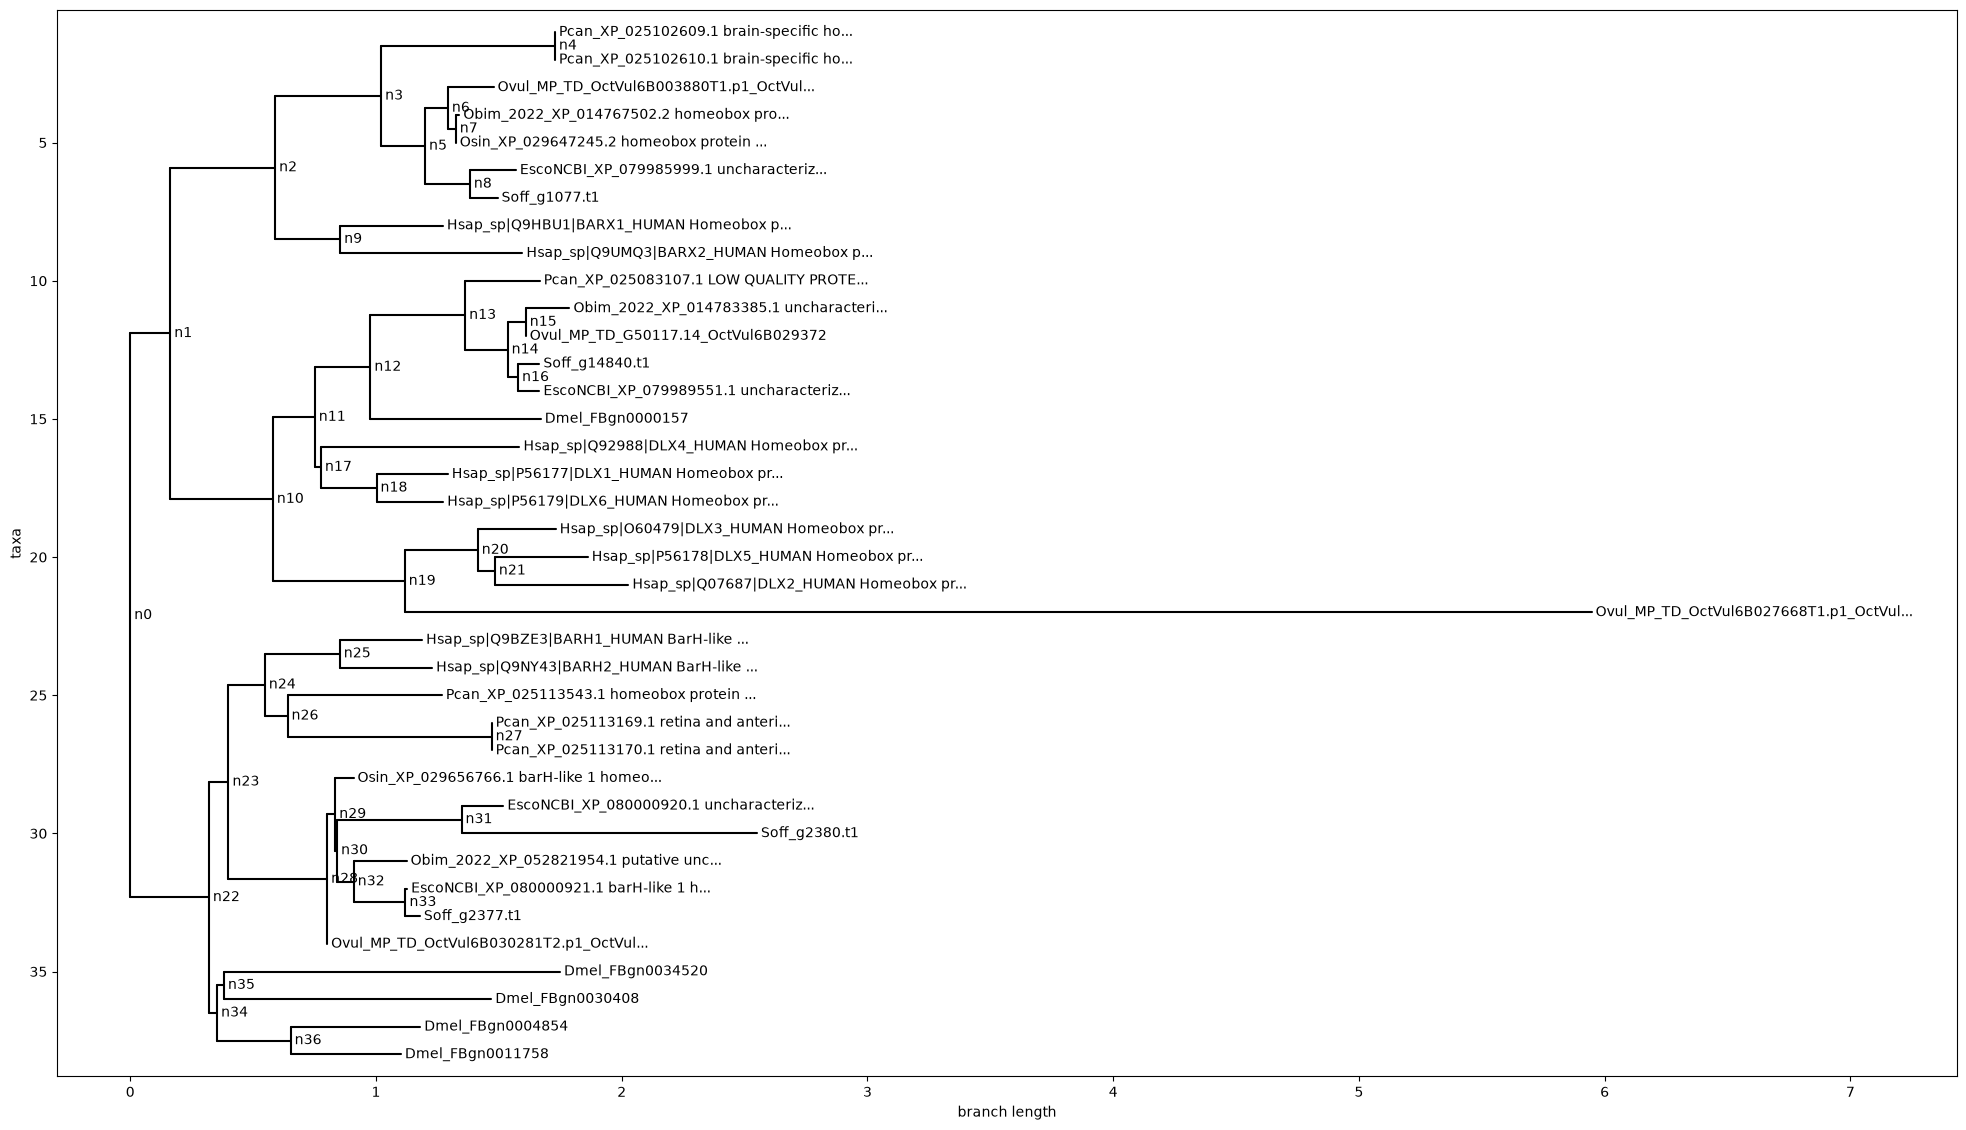

In [13]:
import matplotlib.pyplot as plt
from Bio import Phylo

tree_file = (
    matches_df['tree_file'].loc[0]
)

with open(tree_file, "r") as handle:
    newick_text = handle.read().strip()

fixed_newick = quote_newick_tip_labels(newick_text)

tree = Phylo.read(
    StringIO(fixed_newick),
    "newick"
)

n_tips = len(tree.get_terminals())

fig, ax = plt.subplots(
    figsize=(20, max(5, n_tips * 0.3))
)

Phylo.draw(
    tree,
    axes=ax,
    do_show=False,
    show_confidence=False
)

plt.tight_layout()
plt.show()

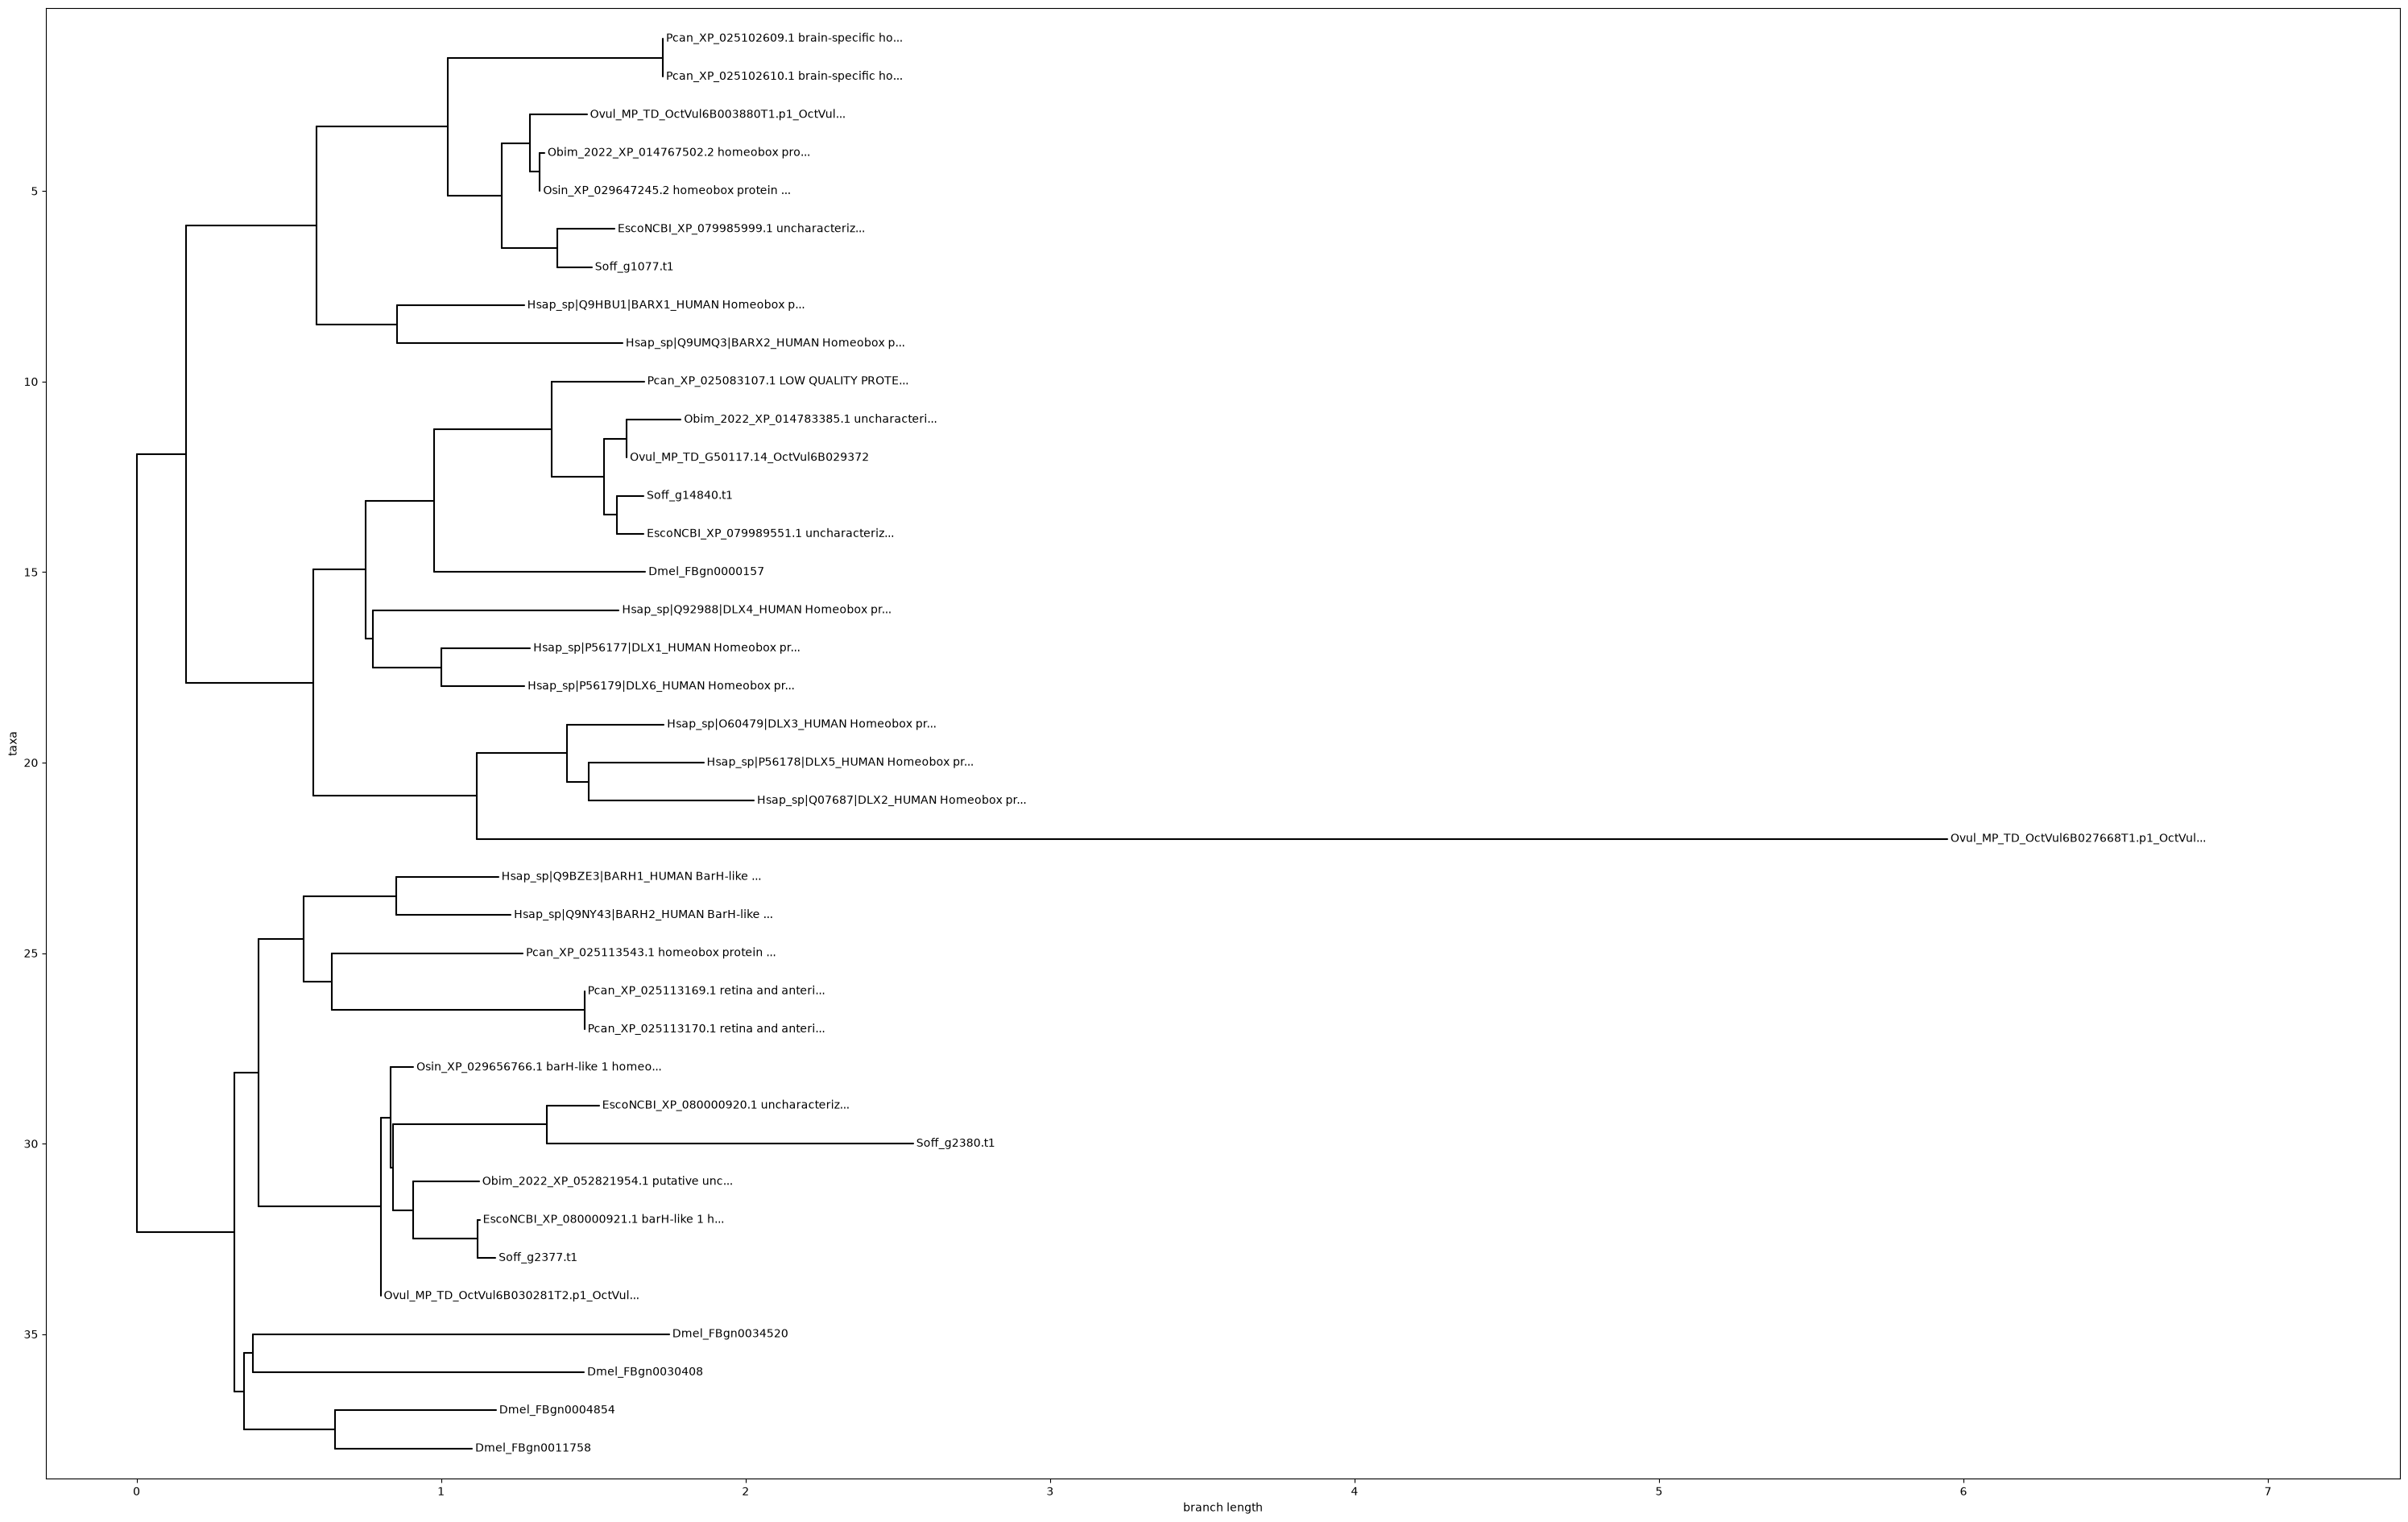

In [14]:
import matplotlib.pyplot as plt
from Bio import Phylo
from io import StringIO

import matplotlib as mpl

mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams["svg.fonttype"] = "none"
mpl.rcParams["font.family"] = "DejaVu Sans"

gene = 'dlx'
tree_file = matches_df.loc[0, "tree_file"]

with open(tree_file, "r") as handle:
    newick_text = handle.read().strip()

fixed_newick = quote_newick_tip_labels(newick_text)

tree = Phylo.read(
    StringIO(fixed_newick),
    "newick"
)

# Remove OrthoFinder internal node labels: n0, n1, n2, ...
for clade in tree.get_nonterminals():
    clade.name = None

n_tips = len(tree.get_terminals())

fig, ax = plt.subplots(
    figsize=(30, max(5, n_tips * 0.5))
)

Phylo.draw(
    tree,
    axes=ax,
    do_show=False,
    show_confidence=False
)

plt.tight_layout()
plt.savefig(f'figures/paper/revision/phylogeny/{gene}_tree.svg', bbox_inches='tight')
plt.show()

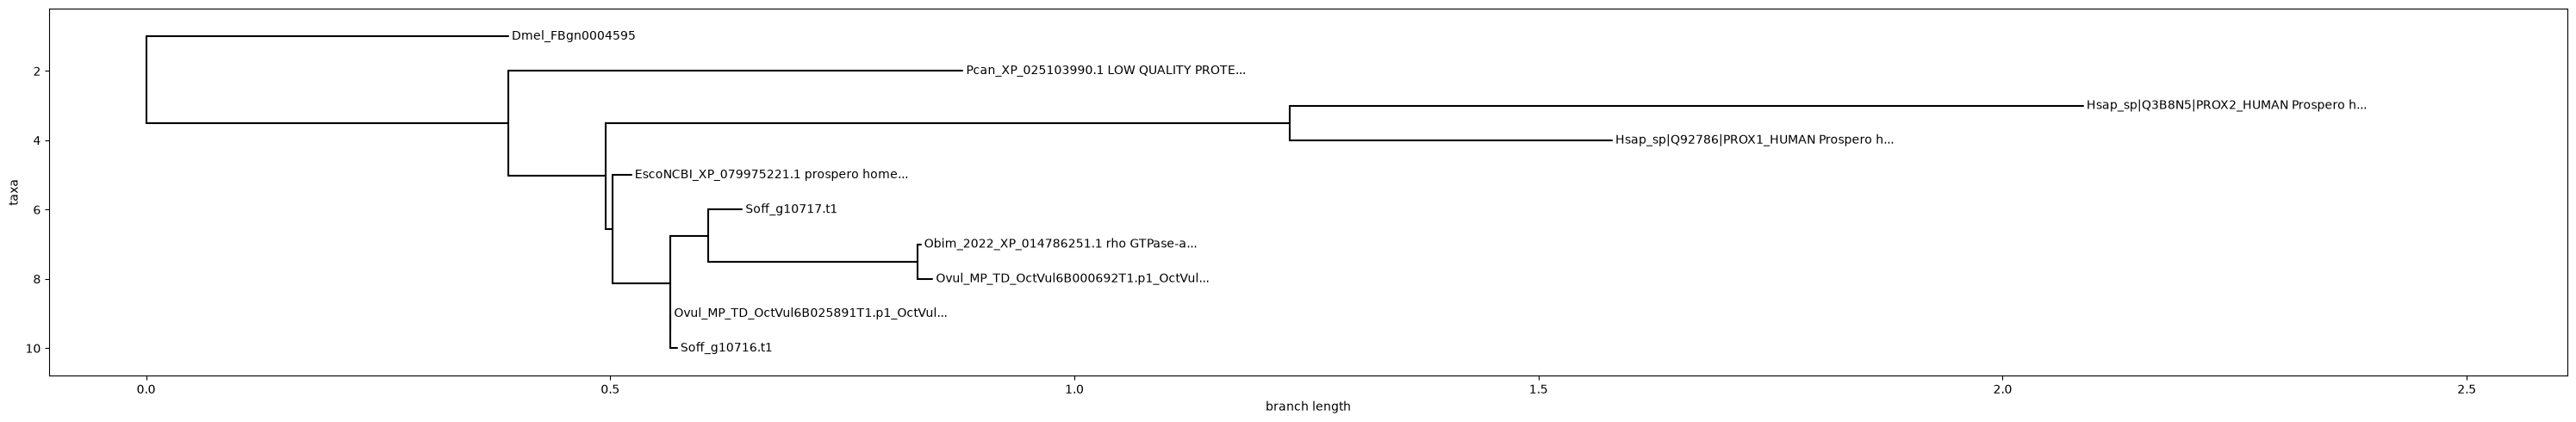

In [15]:
import matplotlib.pyplot as plt
from Bio import Phylo
from io import StringIO

import matplotlib as mpl

mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams["svg.fonttype"] = "none"
mpl.rcParams["font.family"] = "DejaVu Sans"

gene = 'prox'
tree_file = matches_df.loc[1, "tree_file"]

with open(tree_file, "r") as handle:
    newick_text = handle.read().strip()

fixed_newick = quote_newick_tip_labels(newick_text)

tree = Phylo.read(
    StringIO(fixed_newick),
    "newick"
)

# Remove OrthoFinder internal node labels: n0, n1, n2, ...
for clade in tree.get_nonterminals():
    clade.name = None

n_tips = len(tree.get_terminals())

fig, ax = plt.subplots(
    figsize=(30, max(5, n_tips * 0.5))
)

Phylo.draw(
    tree,
    axes=ax,
    do_show=False,
    show_confidence=False
)

plt.tight_layout()
plt.savefig(f'figures/paper/revision/phylogeny/{gene}_tree.svg', bbox_inches='tight')
plt.show()

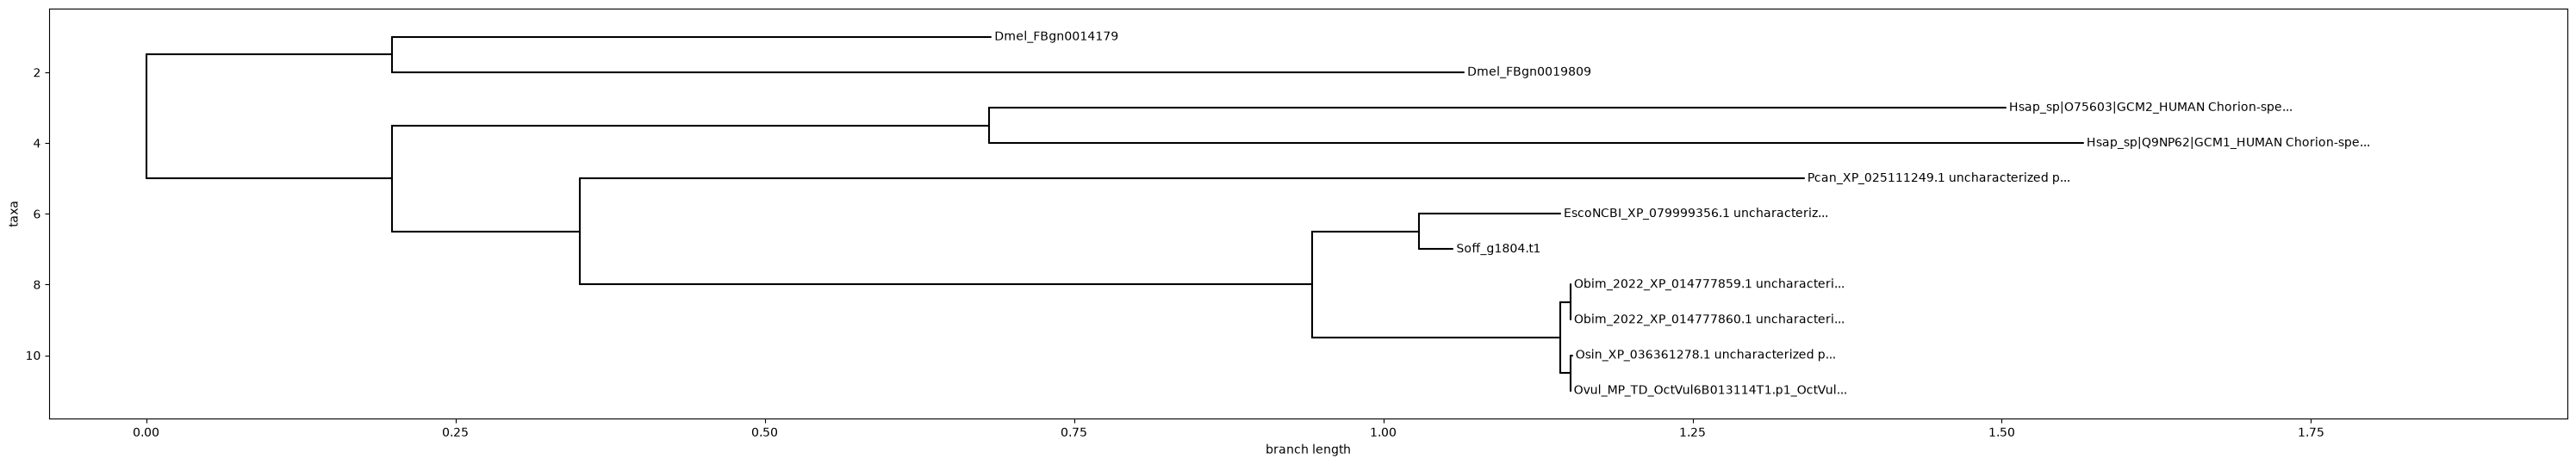

In [16]:
import matplotlib.pyplot as plt
from Bio import Phylo
from io import StringIO

import matplotlib as mpl

mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams["svg.fonttype"] = "none"
mpl.rcParams["font.family"] = "DejaVu Sans"

gene = 'gcm'
tree_file = matches_df.loc[2, "tree_file"]

with open(tree_file, "r") as handle:
    newick_text = handle.read().strip()

fixed_newick = quote_newick_tip_labels(newick_text)

tree = Phylo.read(
    StringIO(fixed_newick),
    "newick"
)

# Remove OrthoFinder internal node labels: n0, n1, n2, ...
for clade in tree.get_nonterminals():
    clade.name = None

n_tips = len(tree.get_terminals())

fig, ax = plt.subplots(
    figsize=(30, max(5, n_tips * 0.5))
)

Phylo.draw(
    tree,
    axes=ax,
    do_show=False,
    show_confidence=False
)

plt.tight_layout()
plt.savefig(f'figures/paper/revision/phylogeny/{gene}_tree.svg', bbox_inches='tight')
plt.show()

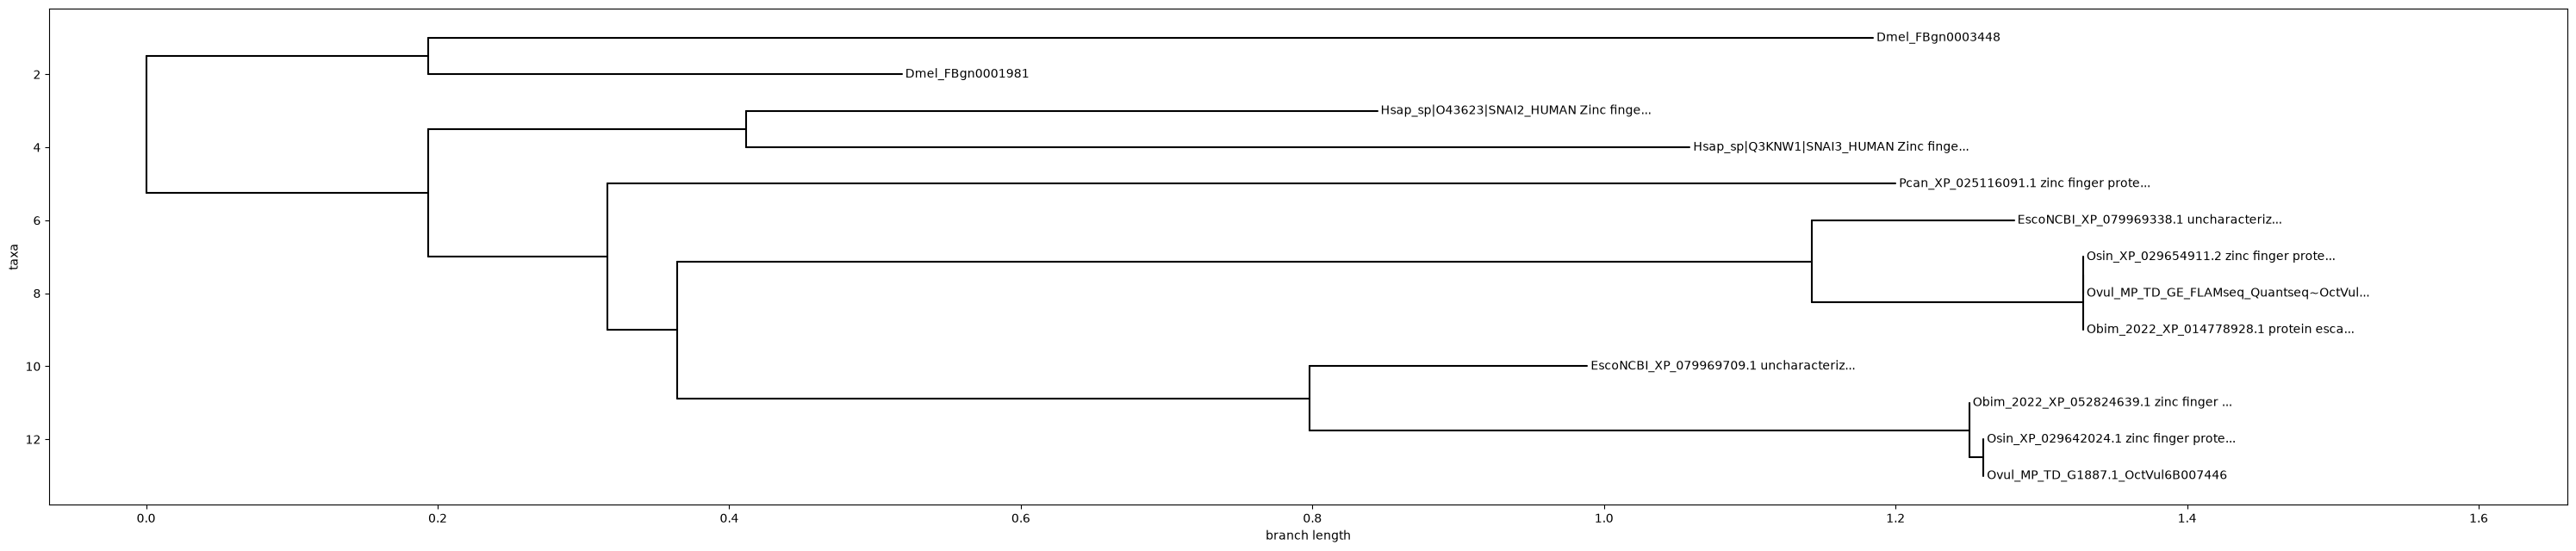

In [17]:
import matplotlib.pyplot as plt
from Bio import Phylo
from io import StringIO

import matplotlib as mpl

mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams["svg.fonttype"] = "none"
mpl.rcParams["font.family"] = "DejaVu Sans"

gene = 'slug'
tree_file = matches_df.loc[3, "tree_file"]

with open(tree_file, "r") as handle:
    newick_text = handle.read().strip()

fixed_newick = quote_newick_tip_labels(newick_text)

tree = Phylo.read(
    StringIO(fixed_newick),
    "newick"
)

# Remove OrthoFinder internal node labels: n0, n1, n2, ...
for clade in tree.get_nonterminals():
    clade.name = None

n_tips = len(tree.get_terminals())

fig, ax = plt.subplots(
    figsize=(30, max(5, n_tips * 0.5))
)

Phylo.draw(
    tree,
    axes=ax,
    do_show=False,
    show_confidence=False
)

plt.tight_layout()
plt.savefig(f'figures/paper/revision/phylogeny/{gene}_tree.svg', bbox_inches='tight')
plt.show()

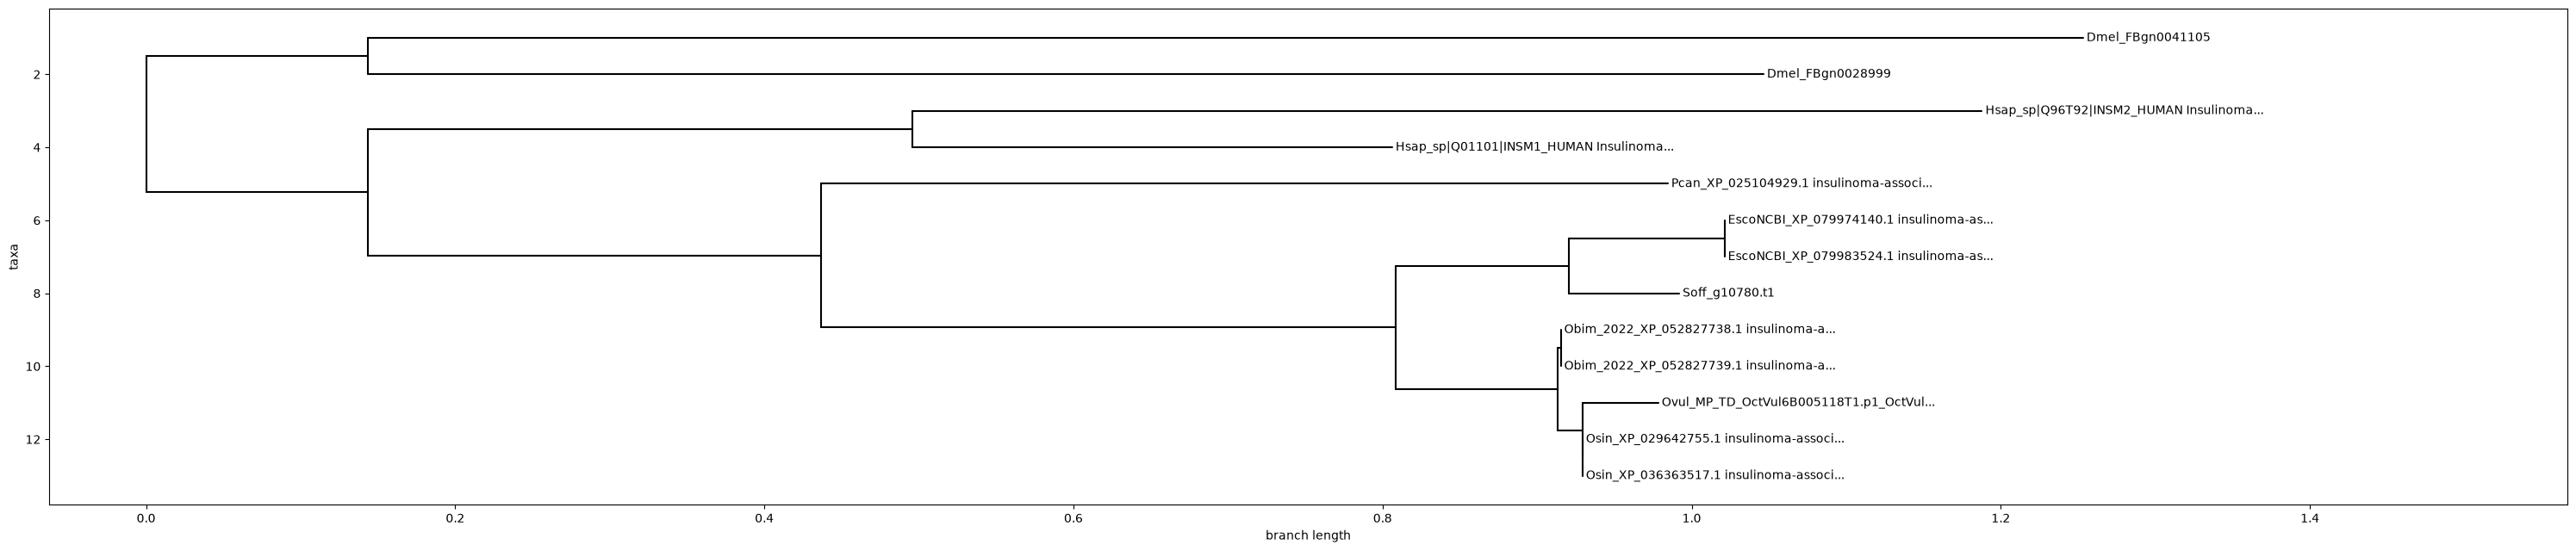

In [18]:
import matplotlib.pyplot as plt
from Bio import Phylo
from io import StringIO

import matplotlib as mpl

mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams["svg.fonttype"] = "none"
mpl.rcParams["font.family"] = "DejaVu Sans"

gene = 'insm'
tree_file = matches_df.loc[4, "tree_file"]

with open(tree_file, "r") as handle:
    newick_text = handle.read().strip()

fixed_newick = quote_newick_tip_labels(newick_text)

tree = Phylo.read(
    StringIO(fixed_newick),
    "newick"
)

# Remove OrthoFinder internal node labels: n0, n1, n2, ...
for clade in tree.get_nonterminals():
    clade.name = None

n_tips = len(tree.get_terminals())

fig, ax = plt.subplots(
    figsize=(30, max(5, n_tips * 0.5))
)

Phylo.draw(
    tree,
    axes=ax,
    do_show=False,
    show_confidence=False
)

plt.tight_layout()
plt.savefig(f'figures/paper/revision/phylogeny/{gene}_tree.svg', bbox_inches='tight')
plt.show()

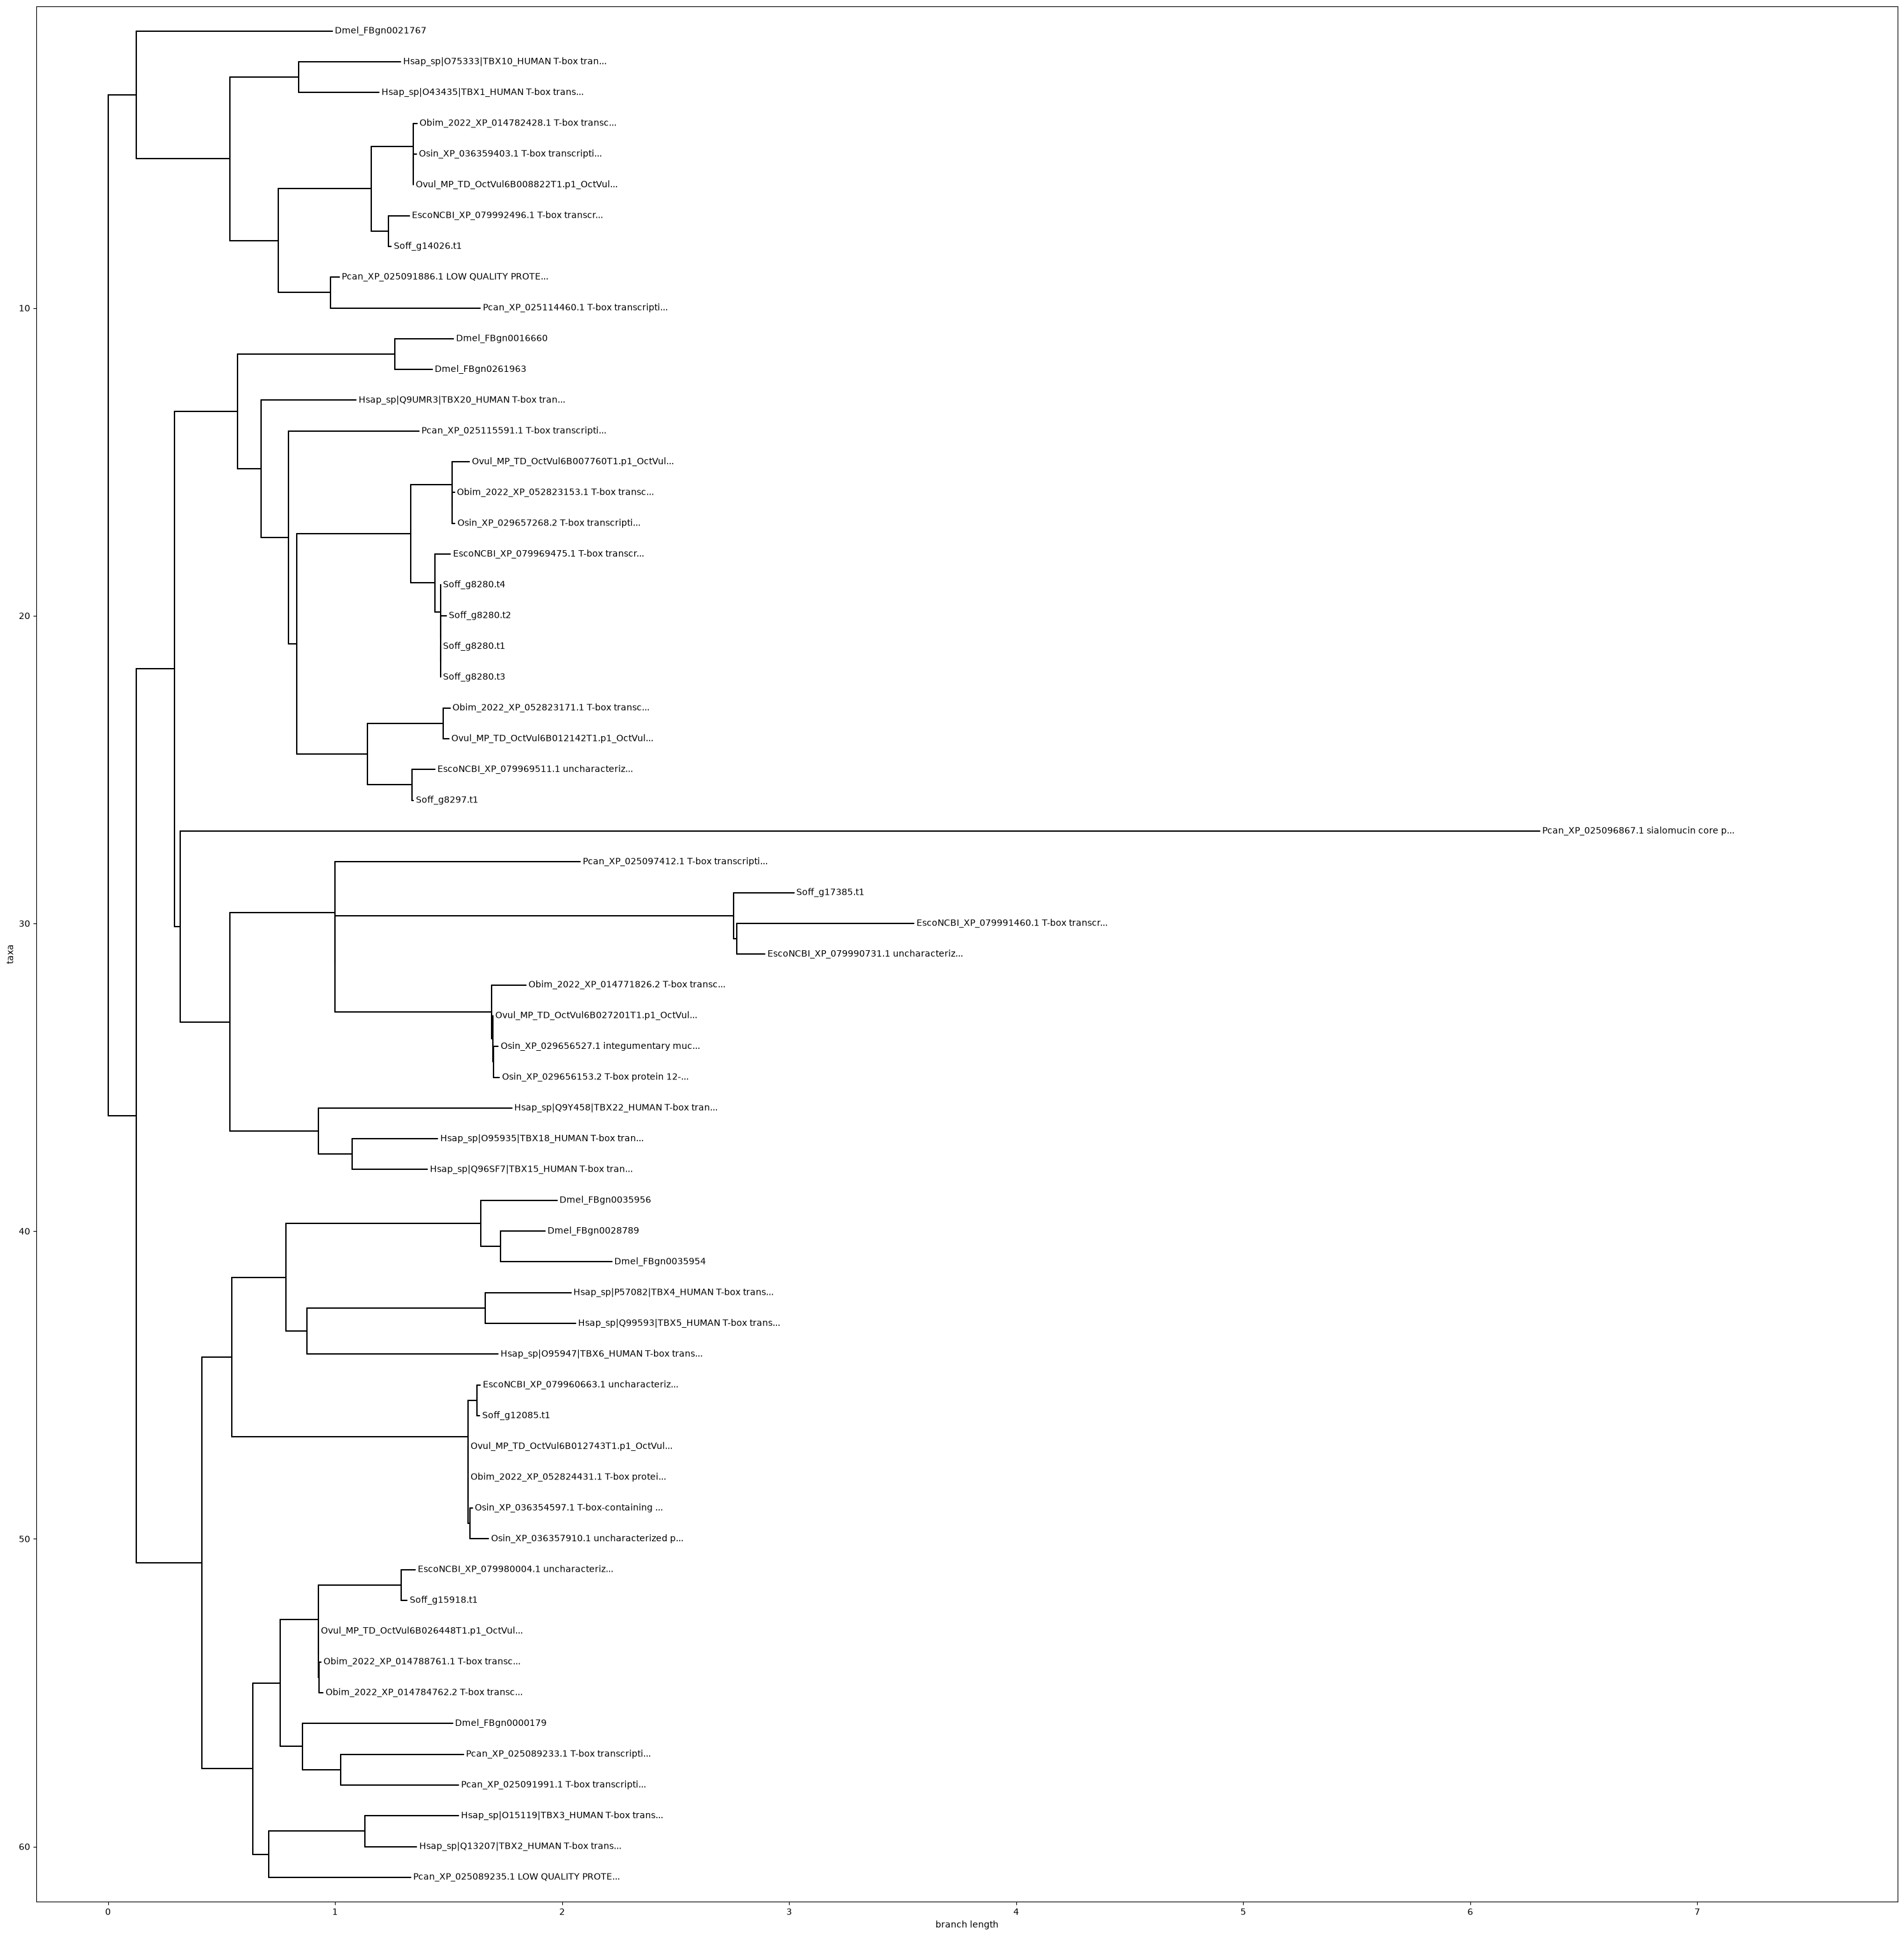

In [19]:
import matplotlib.pyplot as plt
from Bio import Phylo
from io import StringIO

import matplotlib as mpl

mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams["svg.fonttype"] = "none"
mpl.rcParams["font.family"] = "DejaVu Sans"

gene = 'tbx23'
tree_file = matches_df.loc[5, "tree_file"]

with open(tree_file, "r") as handle:
    newick_text = handle.read().strip()

fixed_newick = quote_newick_tip_labels(newick_text)

tree = Phylo.read(
    StringIO(fixed_newick),
    "newick"
)

# Remove OrthoFinder internal node labels: n0, n1, n2, ...
for clade in tree.get_nonterminals():
    clade.name = None

n_tips = len(tree.get_terminals())

fig, ax = plt.subplots(
    figsize=(30, max(5, n_tips * 0.5))
)

Phylo.draw(
    tree,
    axes=ax,
    do_show=False,
    show_confidence=False
)

plt.tight_layout()
plt.savefig(f'figures/paper/revision/phylogeny/{gene}_tree.svg', bbox_inches='tight')
plt.show()

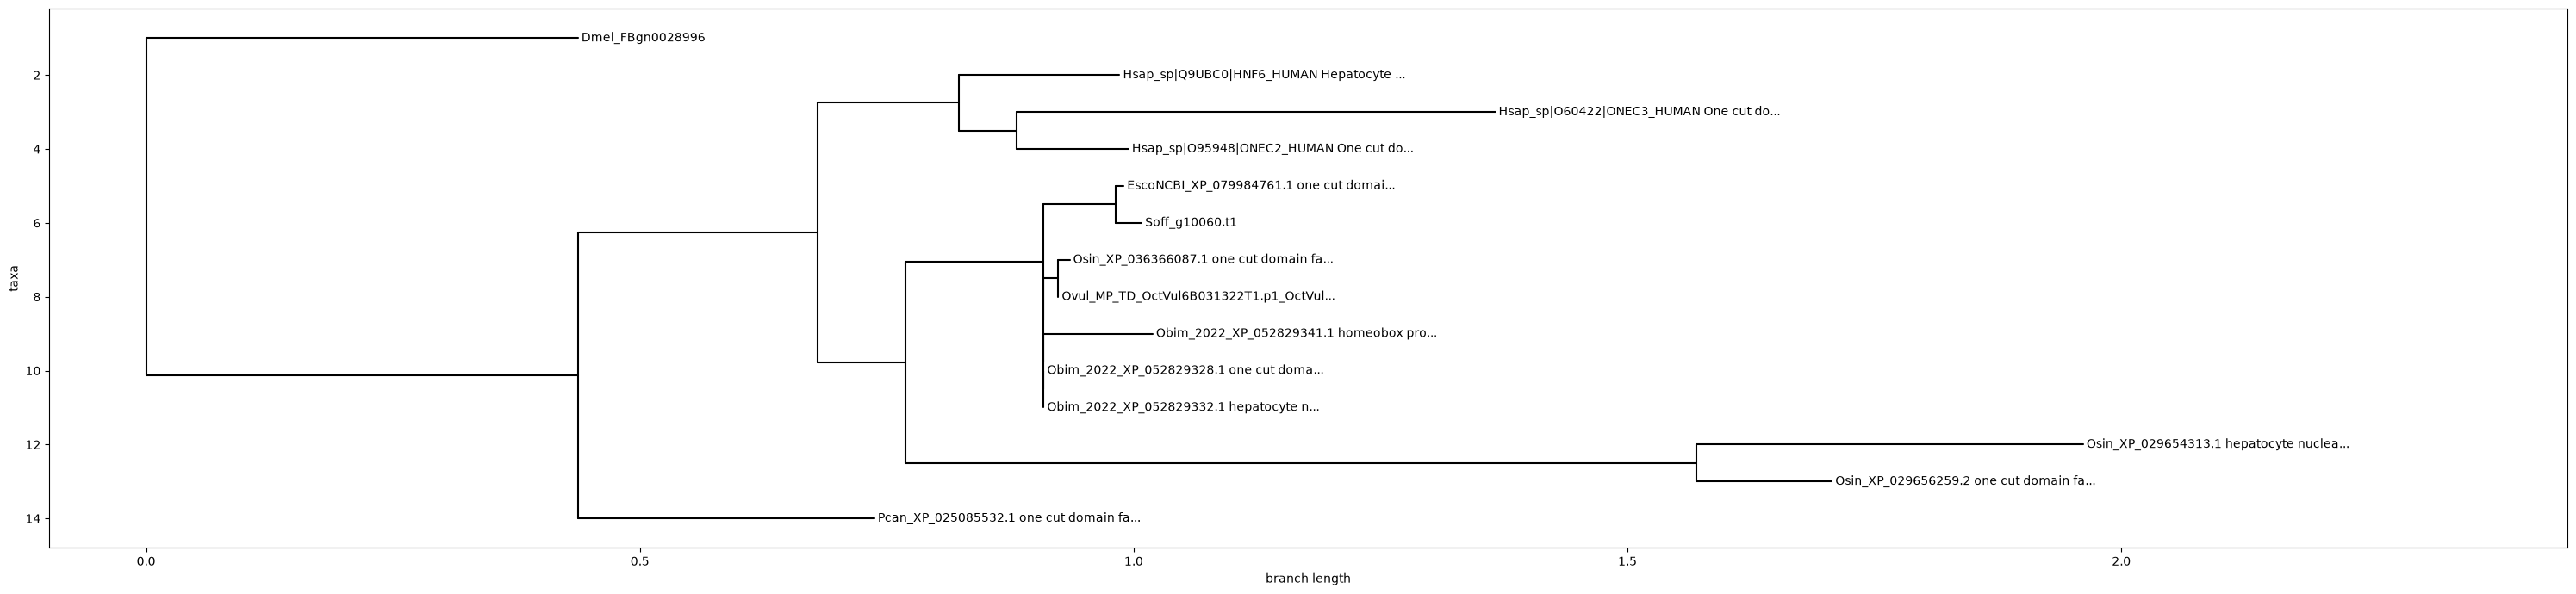

In [20]:
import matplotlib.pyplot as plt
from Bio import Phylo
from io import StringIO

import matplotlib as mpl

mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams["svg.fonttype"] = "none"
mpl.rcParams["font.family"] = "DejaVu Sans"

gene = 'onecut'
tree_file = matches_df.loc[6, "tree_file"]

with open(tree_file, "r") as handle:
    newick_text = handle.read().strip()

fixed_newick = quote_newick_tip_labels(newick_text)

tree = Phylo.read(
    StringIO(fixed_newick),
    "newick"
)

# Remove OrthoFinder internal node labels: n0, n1, n2, ...
for clade in tree.get_nonterminals():
    clade.name = None

n_tips = len(tree.get_terminals())

fig, ax = plt.subplots(
    figsize=(30, max(5, n_tips * 0.5))
)

Phylo.draw(
    tree,
    axes=ax,
    do_show=False,
    show_confidence=False
)

plt.tight_layout()
plt.savefig(f'figures/paper/revision/phylogeny/{gene}_tree.svg', bbox_inches='tight')
plt.show()

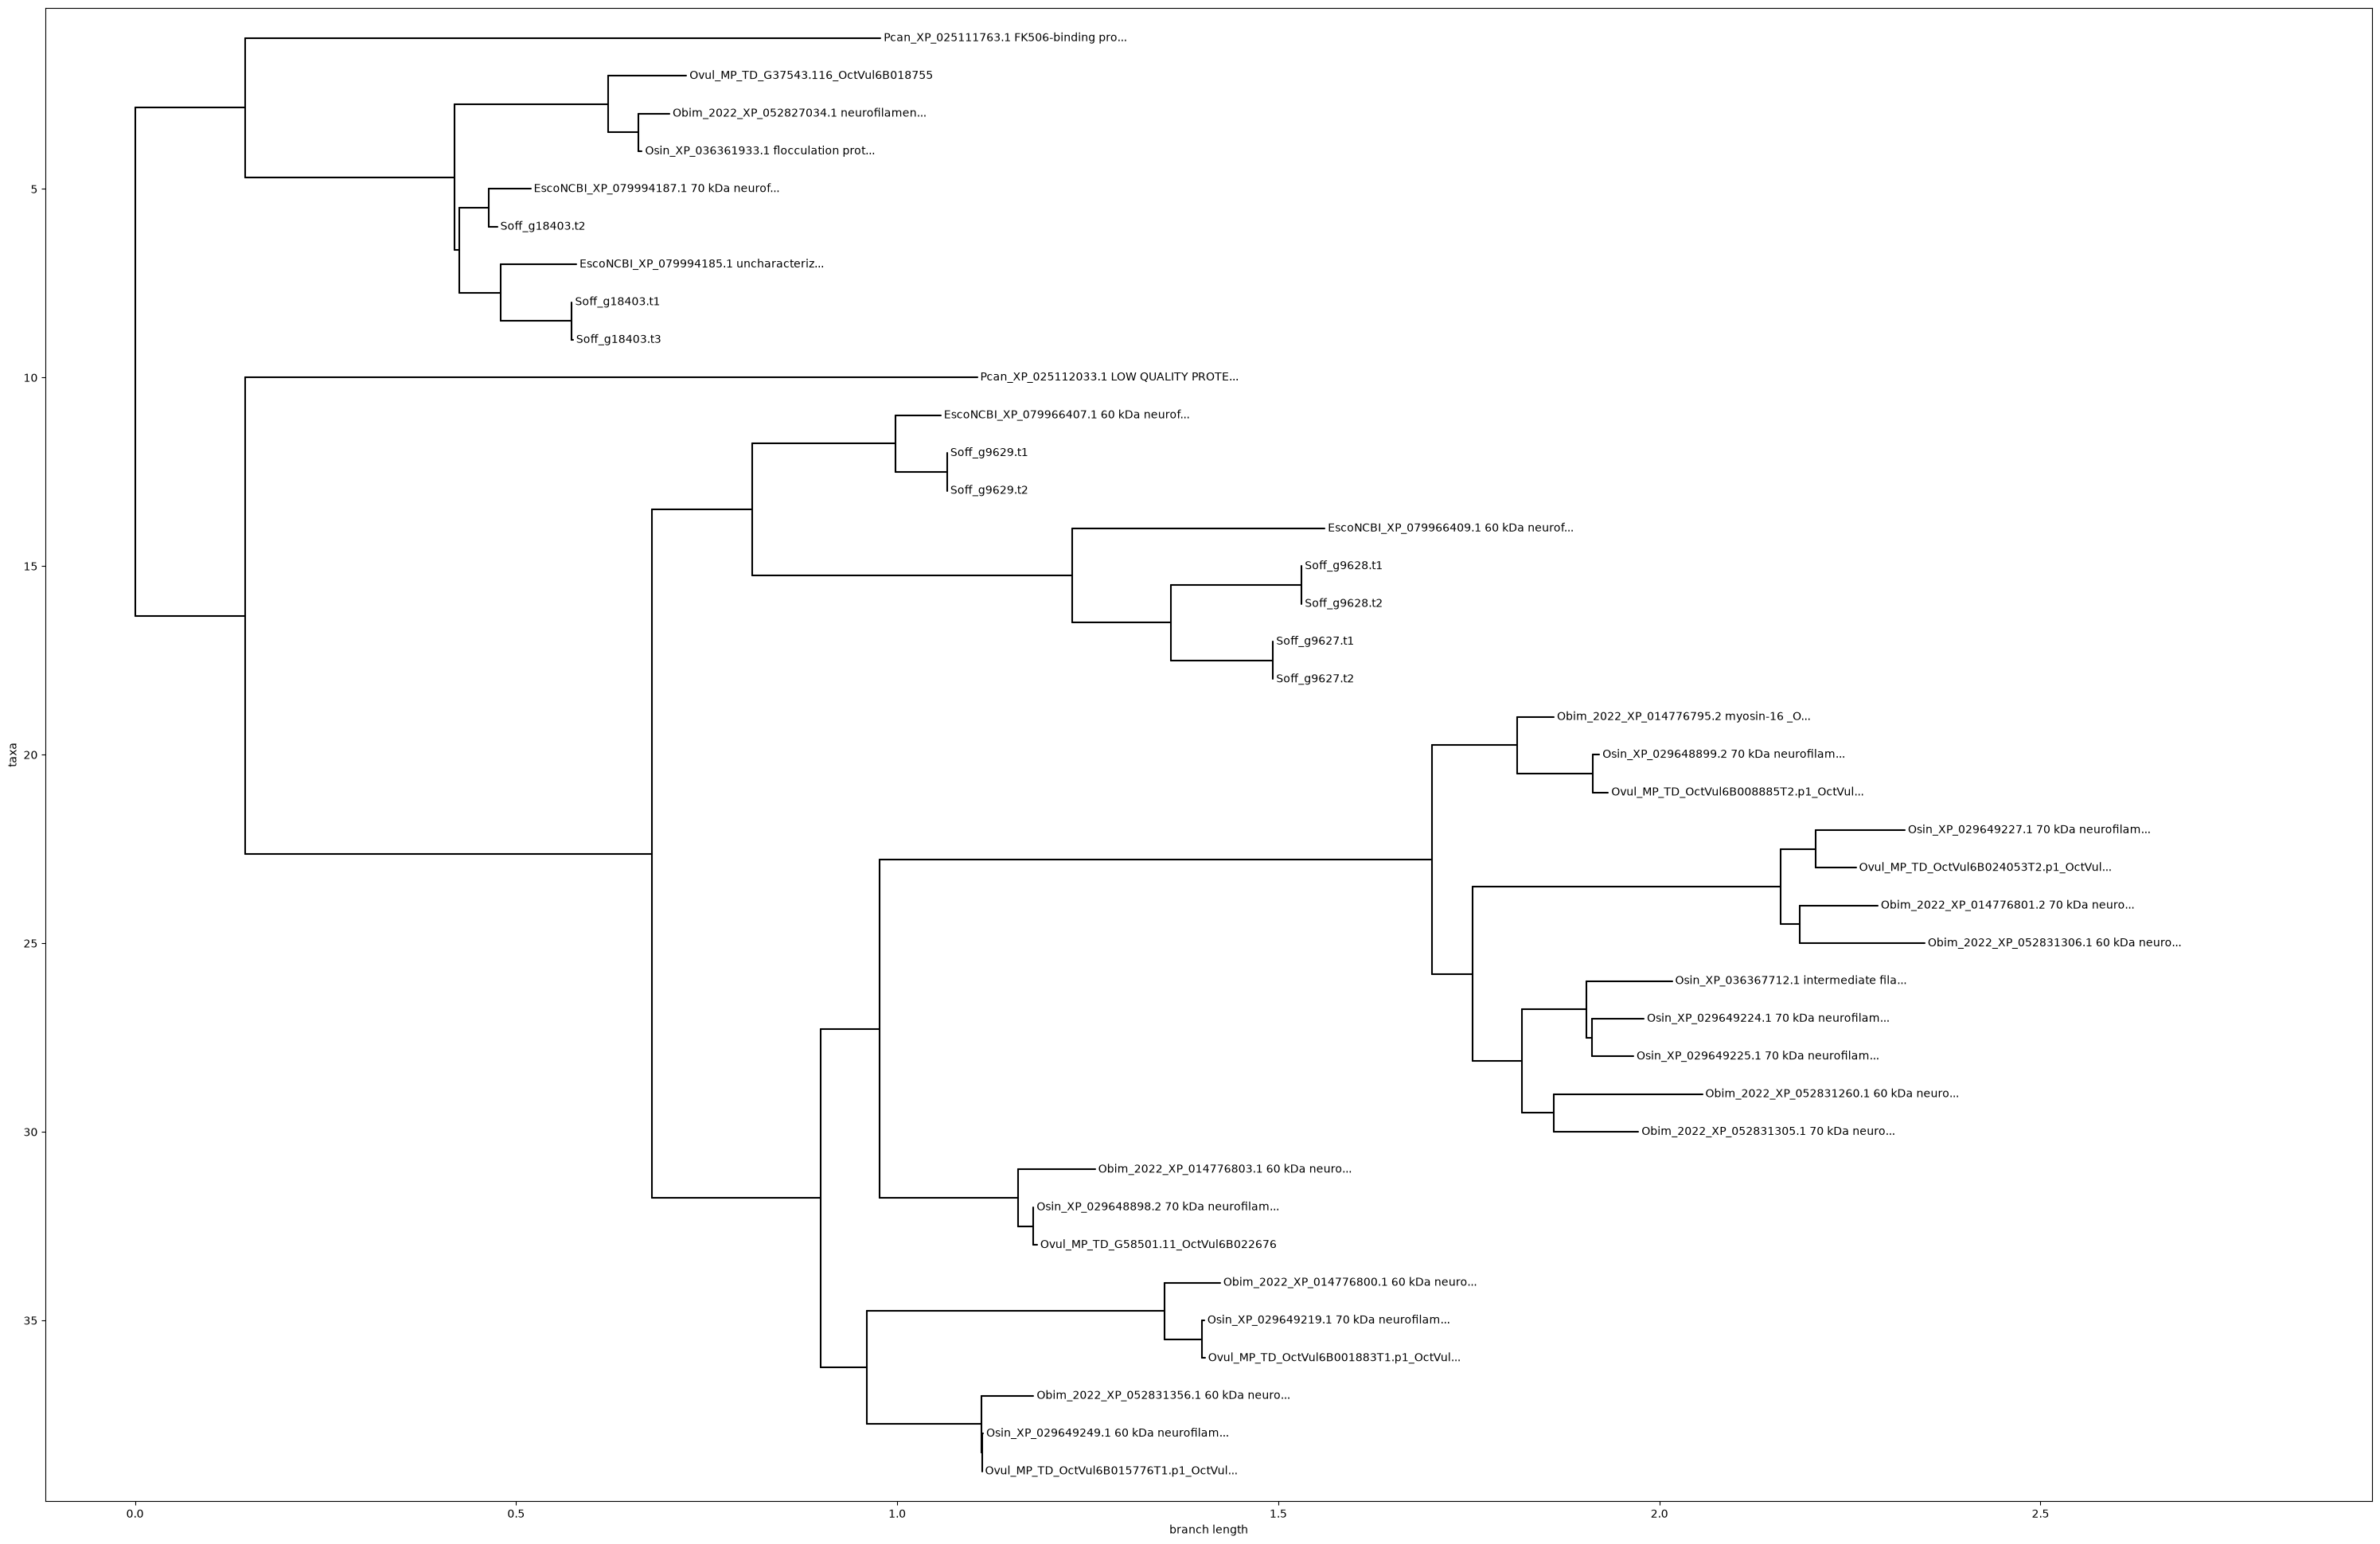

In [21]:
import matplotlib.pyplot as plt
from Bio import Phylo
from io import StringIO

import matplotlib as mpl

mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams["svg.fonttype"] = "none"
mpl.rcParams["font.family"] = "DejaVu Sans"

gene = 'gif'
tree_file = matches_df.loc[7, "tree_file"]

with open(tree_file, "r") as handle:
    newick_text = handle.read().strip()

fixed_newick = quote_newick_tip_labels(newick_text)

tree = Phylo.read(
    StringIO(fixed_newick),
    "newick"
)

# Remove OrthoFinder internal node labels: n0, n1, n2, ...
for clade in tree.get_nonterminals():
    clade.name = None

n_tips = len(tree.get_terminals())

fig, ax = plt.subplots(
    figsize=(30, max(5, n_tips * 0.5))
)

Phylo.draw(
    tree,
    axes=ax,
    do_show=False,
    show_confidence=False
)

plt.tight_layout()
plt.savefig(f'figures/paper/revision/phylogeny/{gene}_tree.svg', bbox_inches='tight')
plt.show()

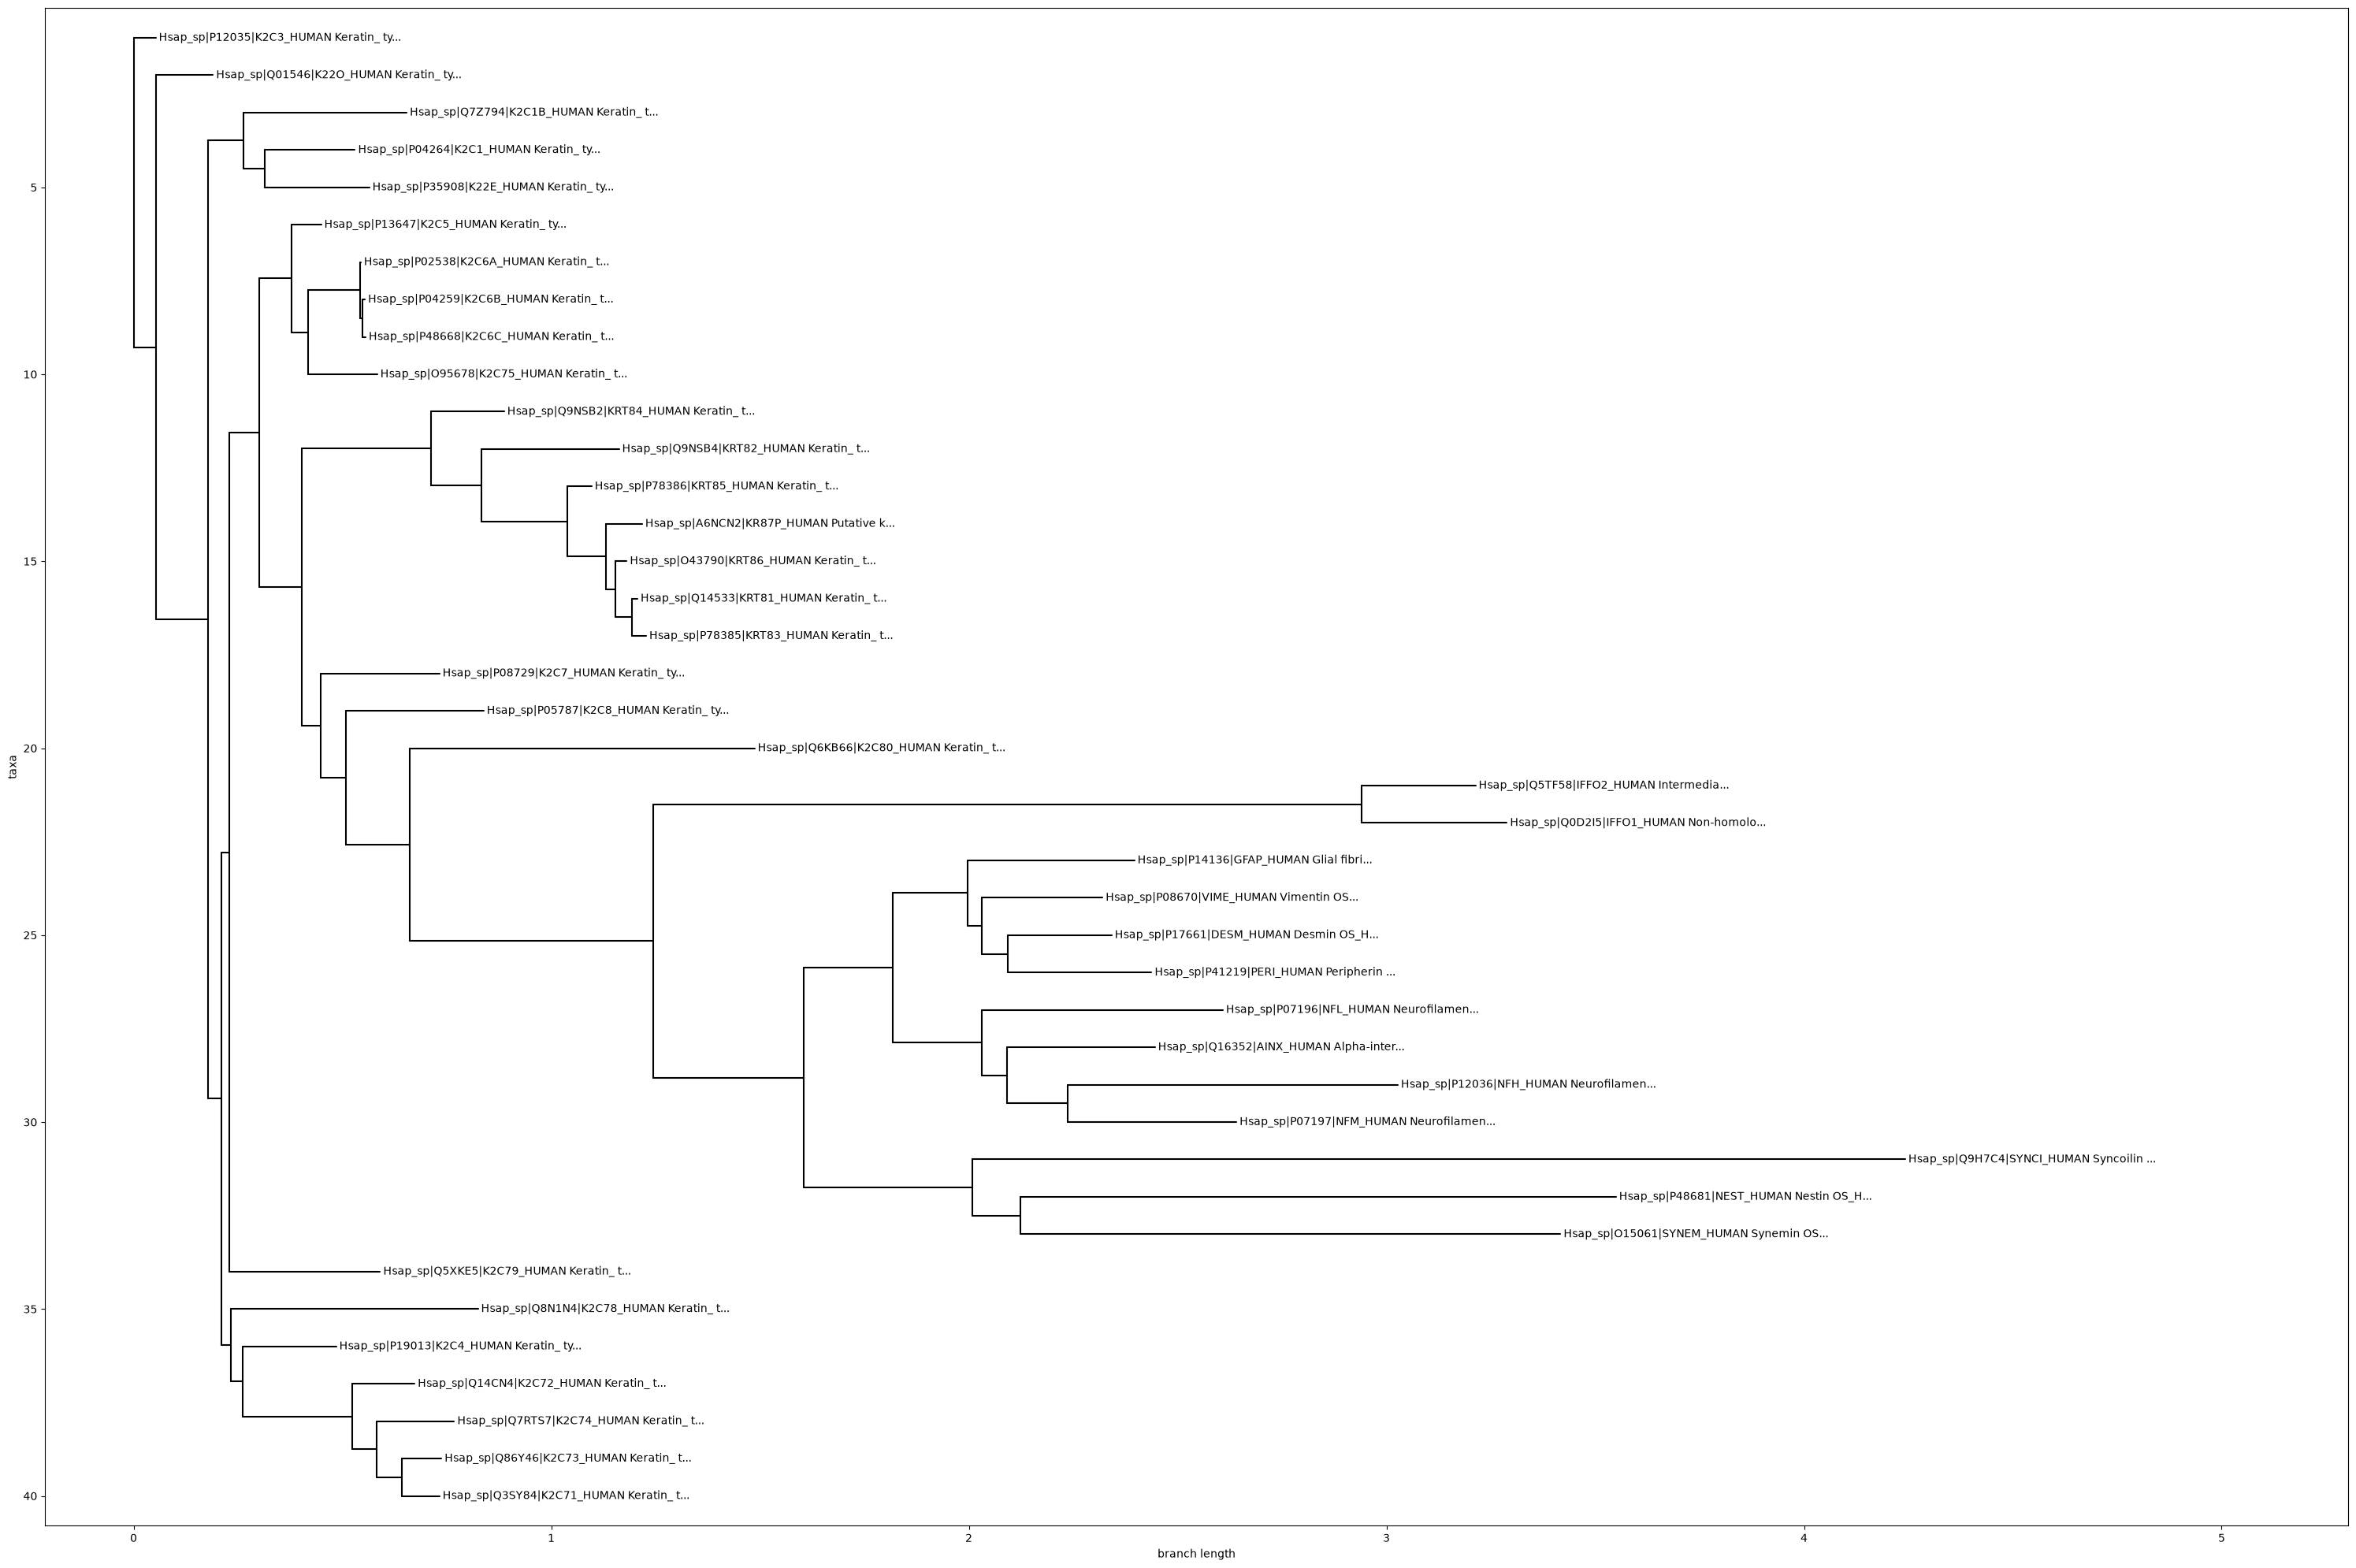

In [22]:
import matplotlib.pyplot as plt
from Bio import Phylo
from io import StringIO

import matplotlib as mpl

mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams["svg.fonttype"] = "none"
mpl.rcParams["font.family"] = "DejaVu Sans"

gene = 'Hs_GFAP'
tree_file = matches_df.loc[8, "tree_file"]

with open(tree_file, "r") as handle:
    newick_text = handle.read().strip()

fixed_newick = quote_newick_tip_labels(newick_text)

tree = Phylo.read(
    StringIO(fixed_newick),
    "newick"
)

# Remove OrthoFinder internal node labels: n0, n1, n2, ...
for clade in tree.get_nonterminals():
    clade.name = None

n_tips = len(tree.get_terminals())

fig, ax = plt.subplots(
    figsize=(30, max(5, n_tips * 0.5))
)

Phylo.draw(
    tree,
    axes=ax,
    do_show=False,
    show_confidence=False
)

plt.tight_layout()
plt.savefig(f'figures/paper/revision/phylogeny/{gene}_tree.svg', bbox_inches='tight')
plt.show()

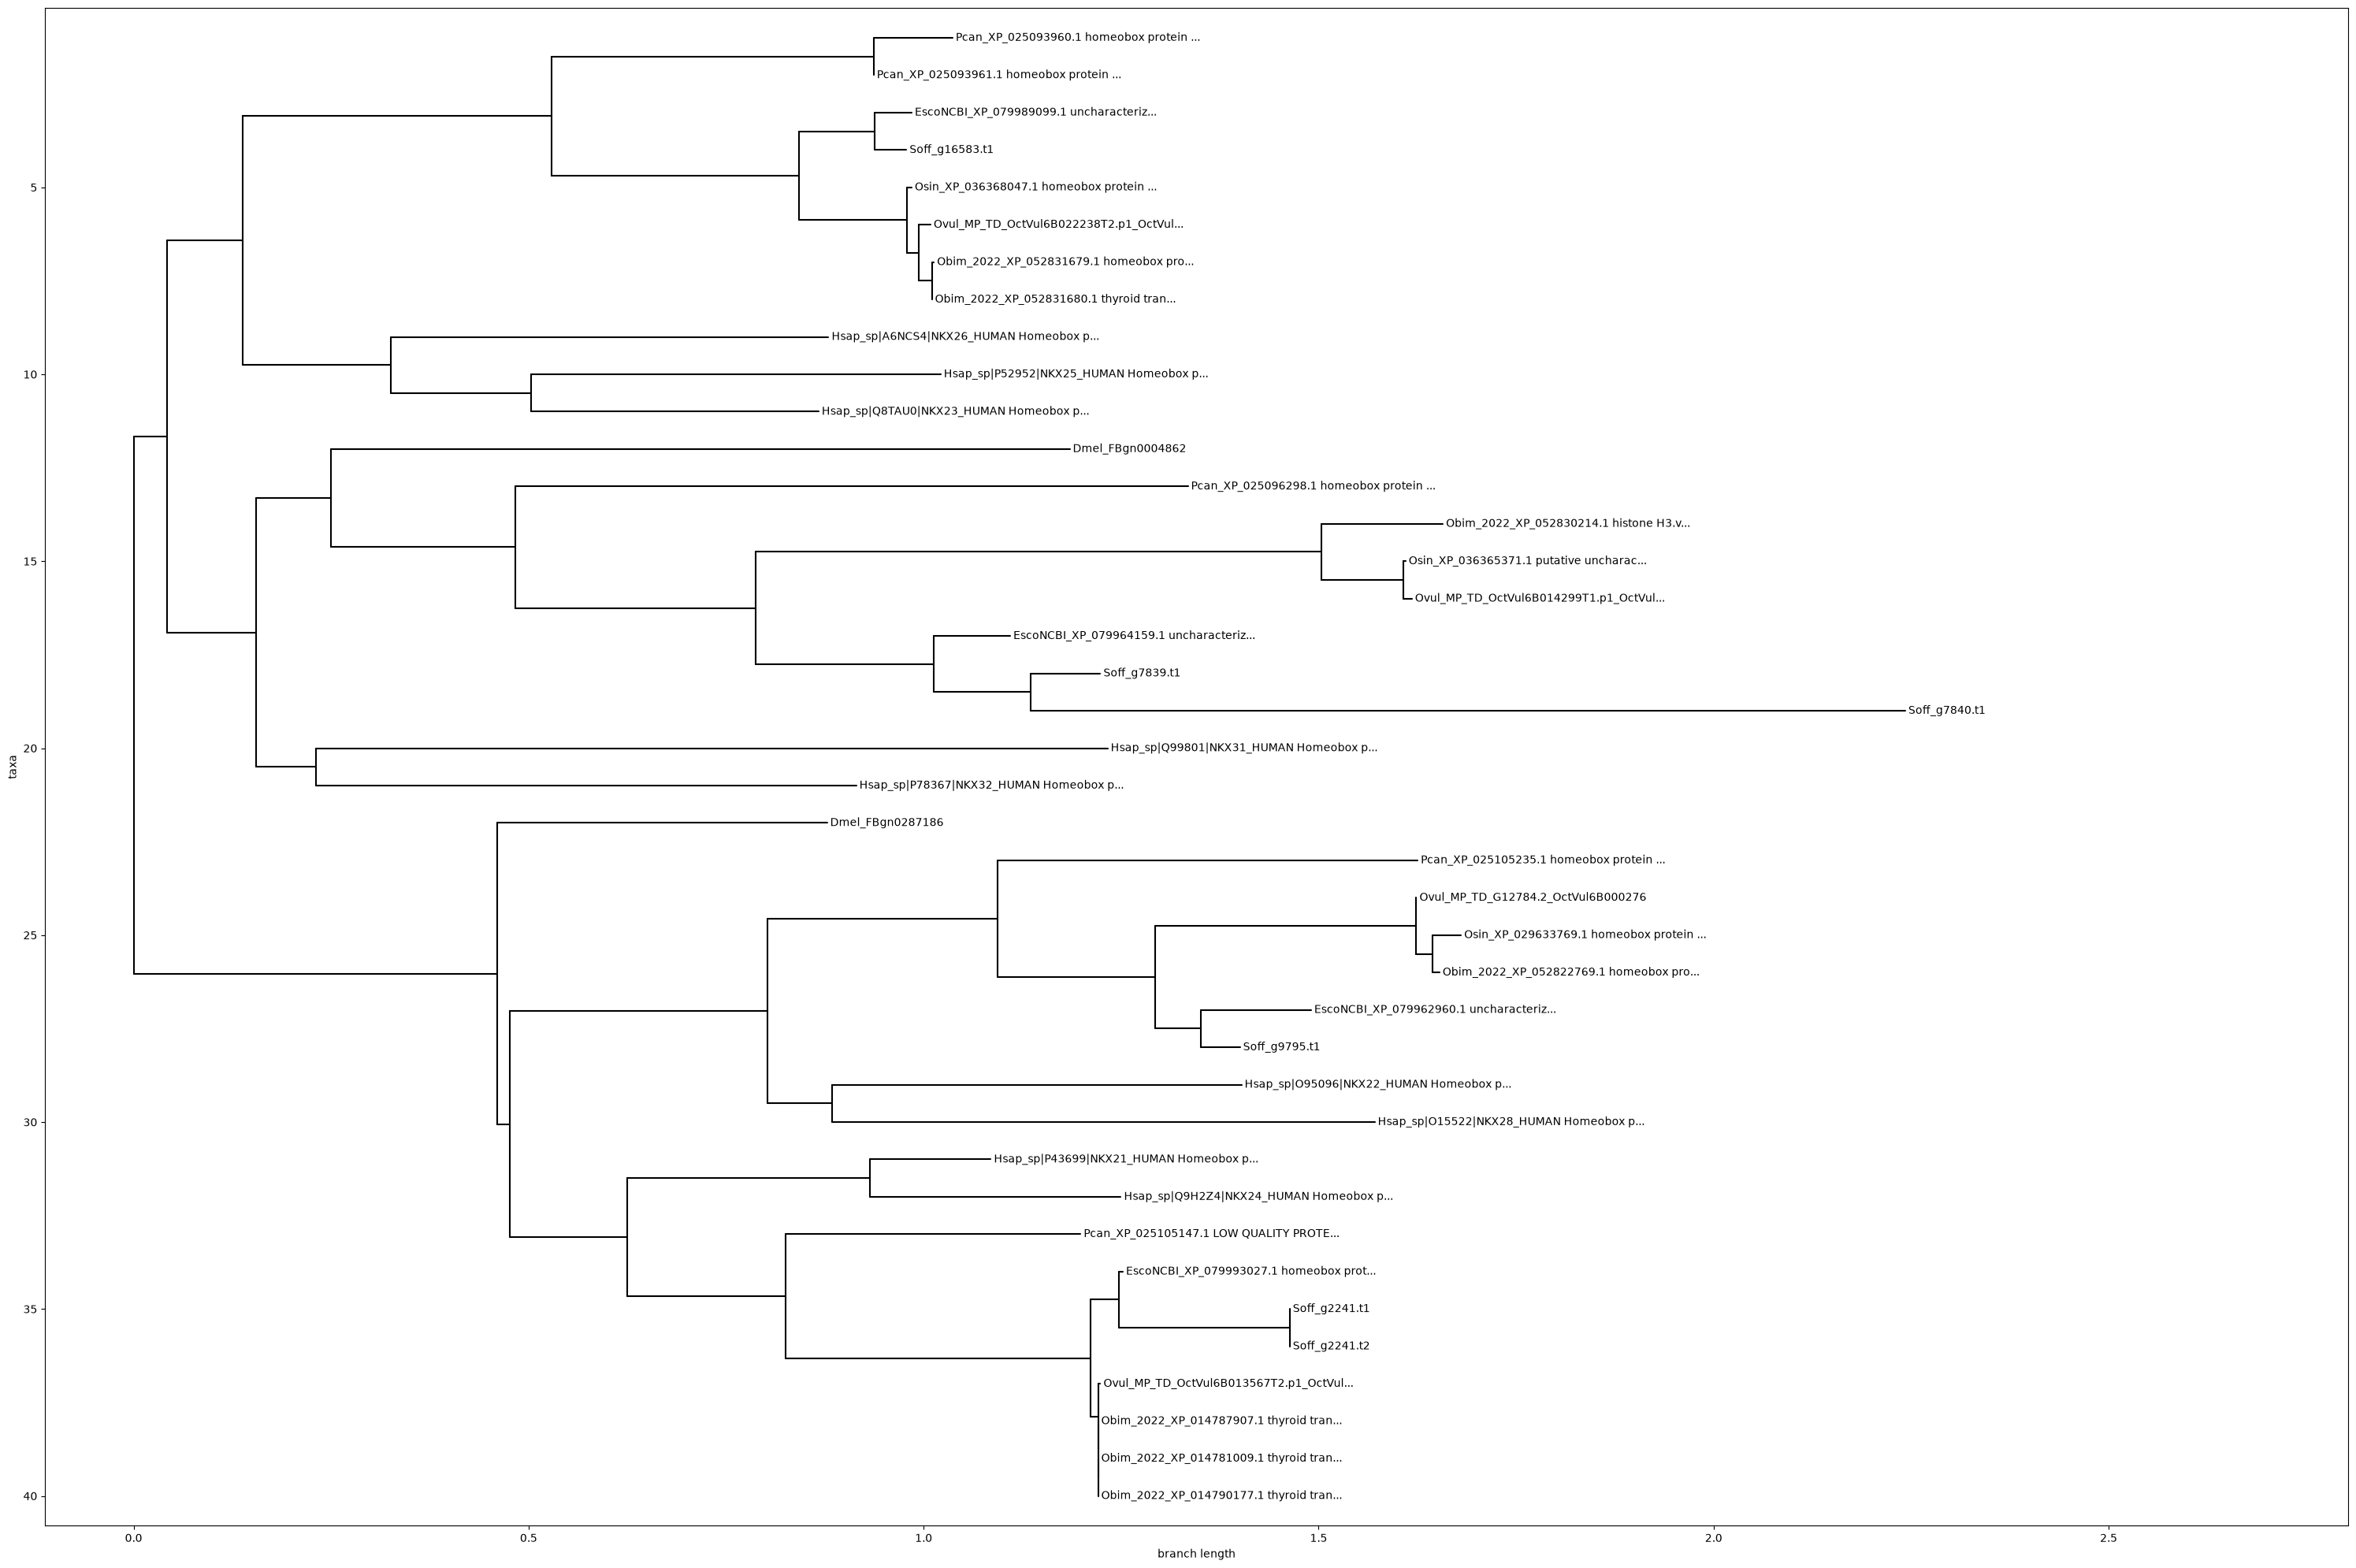

In [23]:
import matplotlib.pyplot as plt
from Bio import Phylo
from io import StringIO

import matplotlib as mpl

mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams["svg.fonttype"] = "none"
mpl.rcParams["font.family"] = "DejaVu Sans"

gene = 'nkx21'
tree_file = matches_df.loc[9, "tree_file"]

with open(tree_file, "r") as handle:
    newick_text = handle.read().strip()

fixed_newick = quote_newick_tip_labels(newick_text)

tree = Phylo.read(
    StringIO(fixed_newick),
    "newick"
)

# Remove OrthoFinder internal node labels: n0, n1, n2, ...
for clade in tree.get_nonterminals():
    clade.name = None

n_tips = len(tree.get_terminals())

fig, ax = plt.subplots(
    figsize=(30, max(5, n_tips * 0.5))
)

Phylo.draw(
    tree,
    axes=ax,
    do_show=False,
    show_confidence=False
)

plt.tight_layout()
plt.savefig(f'figures/paper/revision/phylogeny/{gene}_tree.svg', bbox_inches='tight')
plt.show()

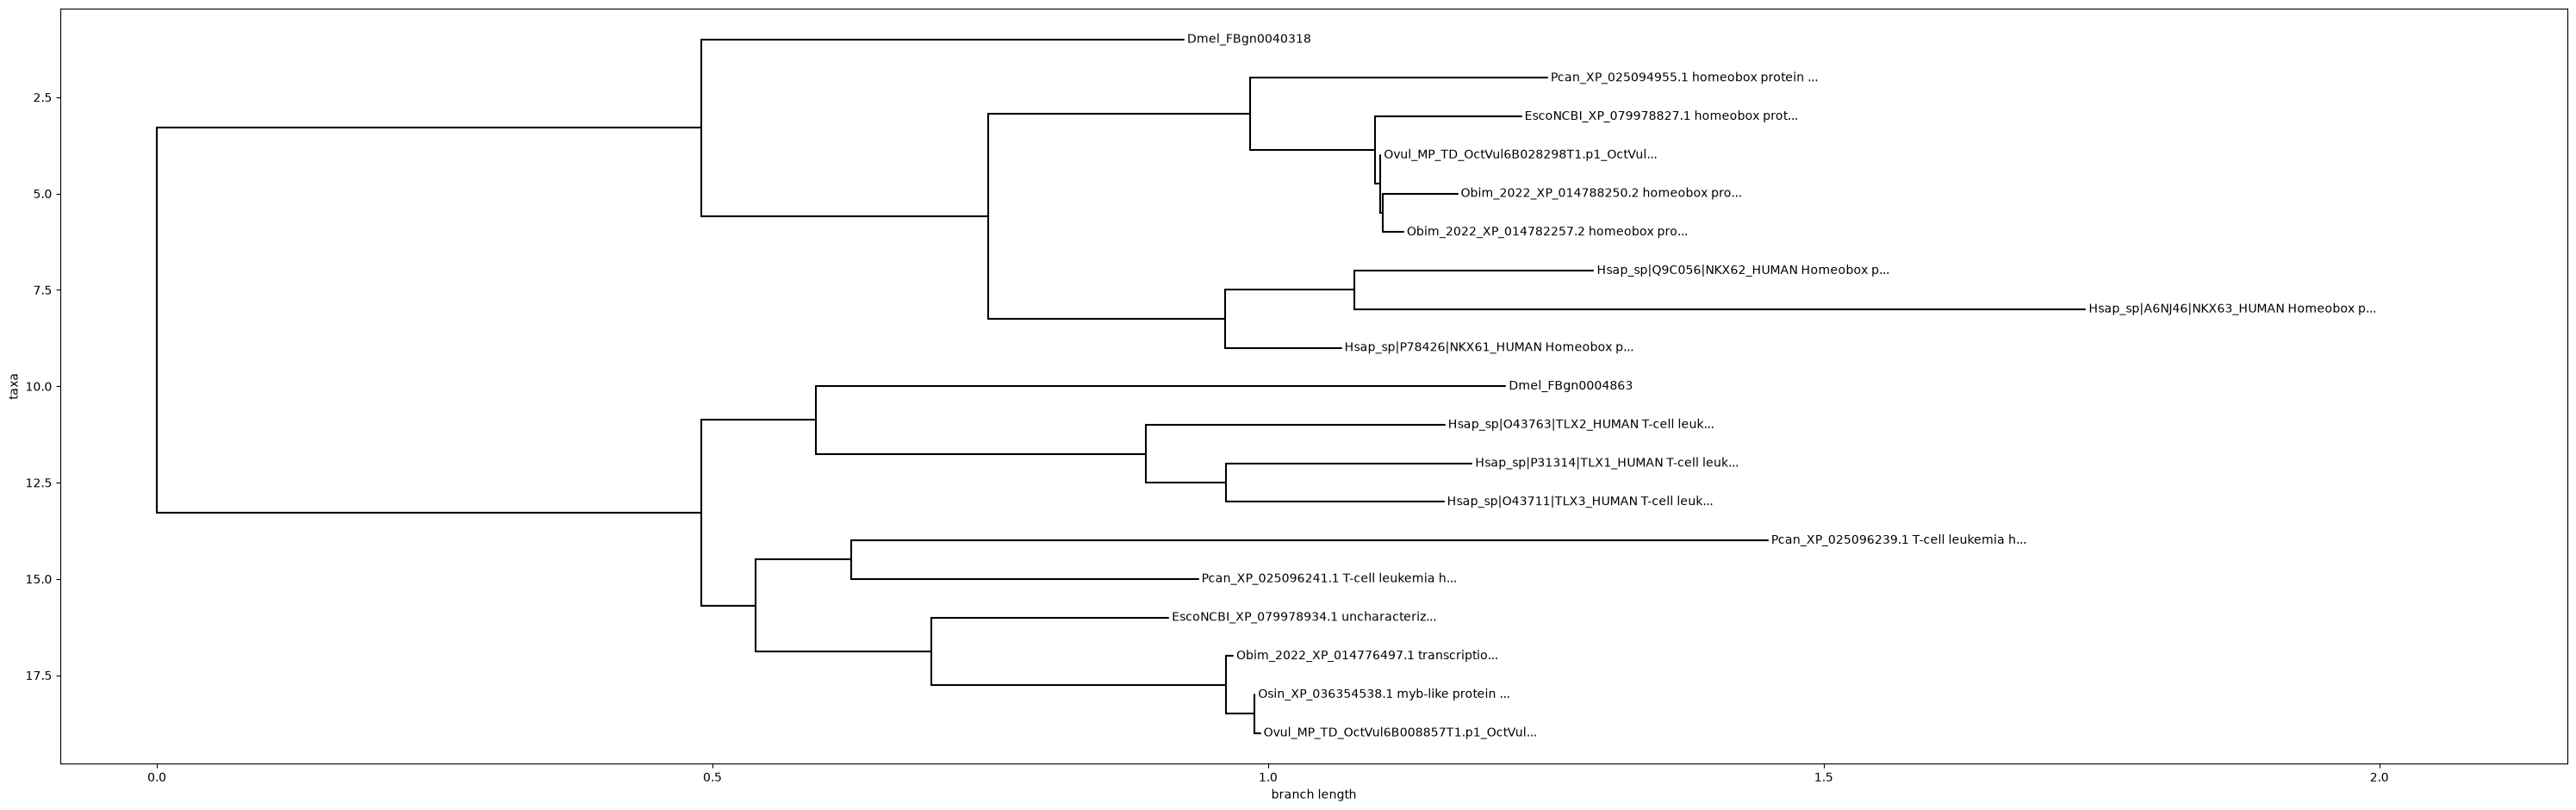

In [24]:
import matplotlib.pyplot as plt
from Bio import Phylo
from io import StringIO

import matplotlib as mpl

mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams["svg.fonttype"] = "none"
mpl.rcParams["font.family"] = "DejaVu Sans"

gene = 'nkx61'
tree_file = matches_df.loc[10, "tree_file"]

with open(tree_file, "r") as handle:
    newick_text = handle.read().strip()

fixed_newick = quote_newick_tip_labels(newick_text)

tree = Phylo.read(
    StringIO(fixed_newick),
    "newick"
)

# Remove OrthoFinder internal node labels: n0, n1, n2, ...
for clade in tree.get_nonterminals():
    clade.name = None

n_tips = len(tree.get_terminals())

fig, ax = plt.subplots(
    figsize=(30, max(5, n_tips * 0.5))
)

Phylo.draw(
    tree,
    axes=ax,
    do_show=False,
    show_confidence=False
)

plt.tight_layout()
plt.savefig(f'figures/paper/revision/phylogeny/{gene}_tree.svg', bbox_inches='tight')
plt.show()

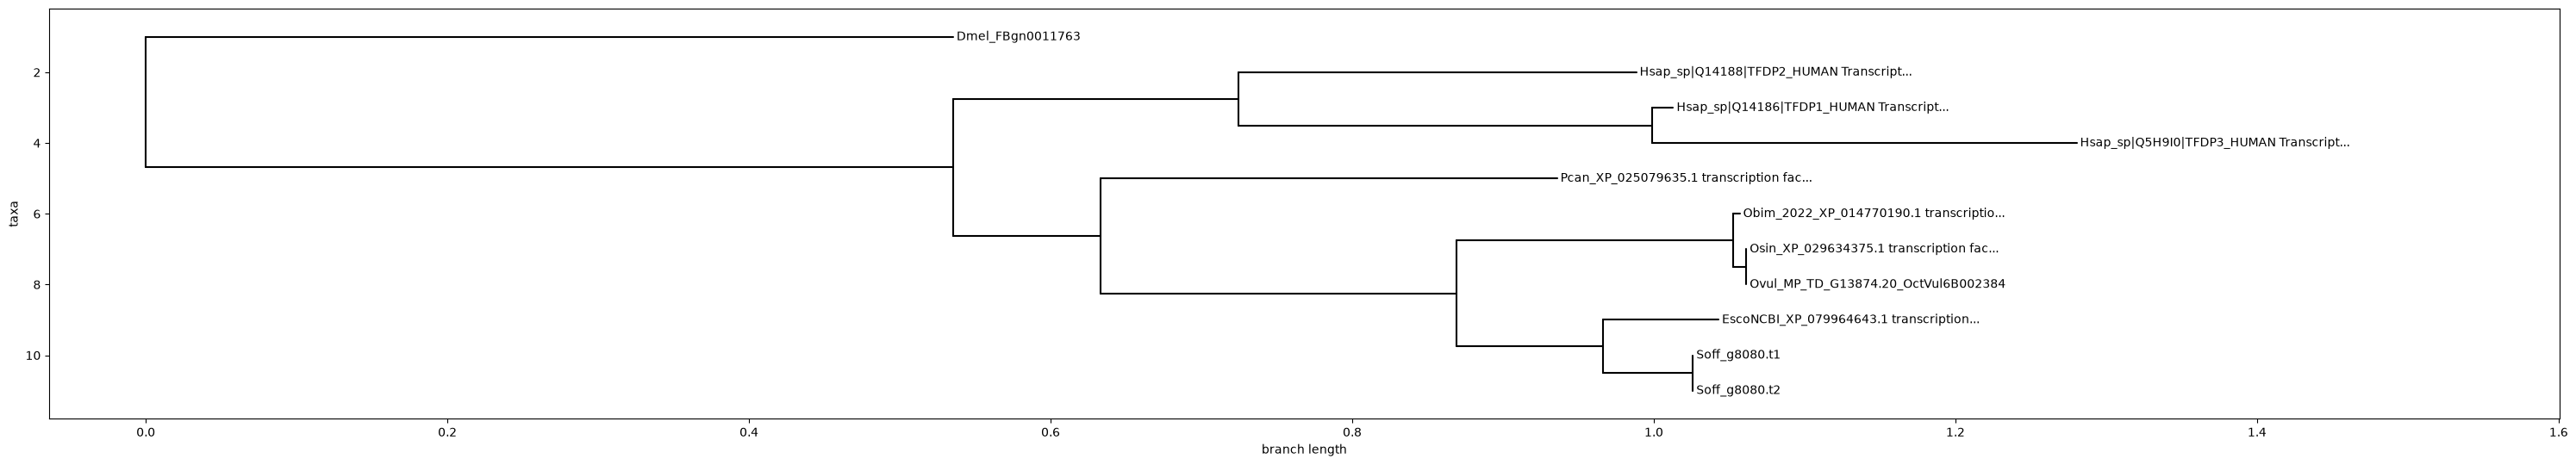

In [25]:
import matplotlib.pyplot as plt
from Bio import Phylo
from io import StringIO

import matplotlib as mpl

mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams["svg.fonttype"] = "none"
mpl.rcParams["font.family"] = "DejaVu Sans"

gene = 'tfdp'
tree_file = matches_df.loc[11, "tree_file"]

with open(tree_file, "r") as handle:
    newick_text = handle.read().strip()

fixed_newick = quote_newick_tip_labels(newick_text)

tree = Phylo.read(
    StringIO(fixed_newick),
    "newick"
)

# Remove OrthoFinder internal node labels: n0, n1, n2, ...
for clade in tree.get_nonterminals():
    clade.name = None

n_tips = len(tree.get_terminals())

fig, ax = plt.subplots(
    figsize=(30, max(5, n_tips * 0.5))
)

Phylo.draw(
    tree,
    axes=ax,
    do_show=False,
    show_confidence=False
)

plt.tight_layout()
plt.savefig(f'figures/paper/revision/phylogeny/{gene}_tree.svg', bbox_inches='tight')
plt.show()

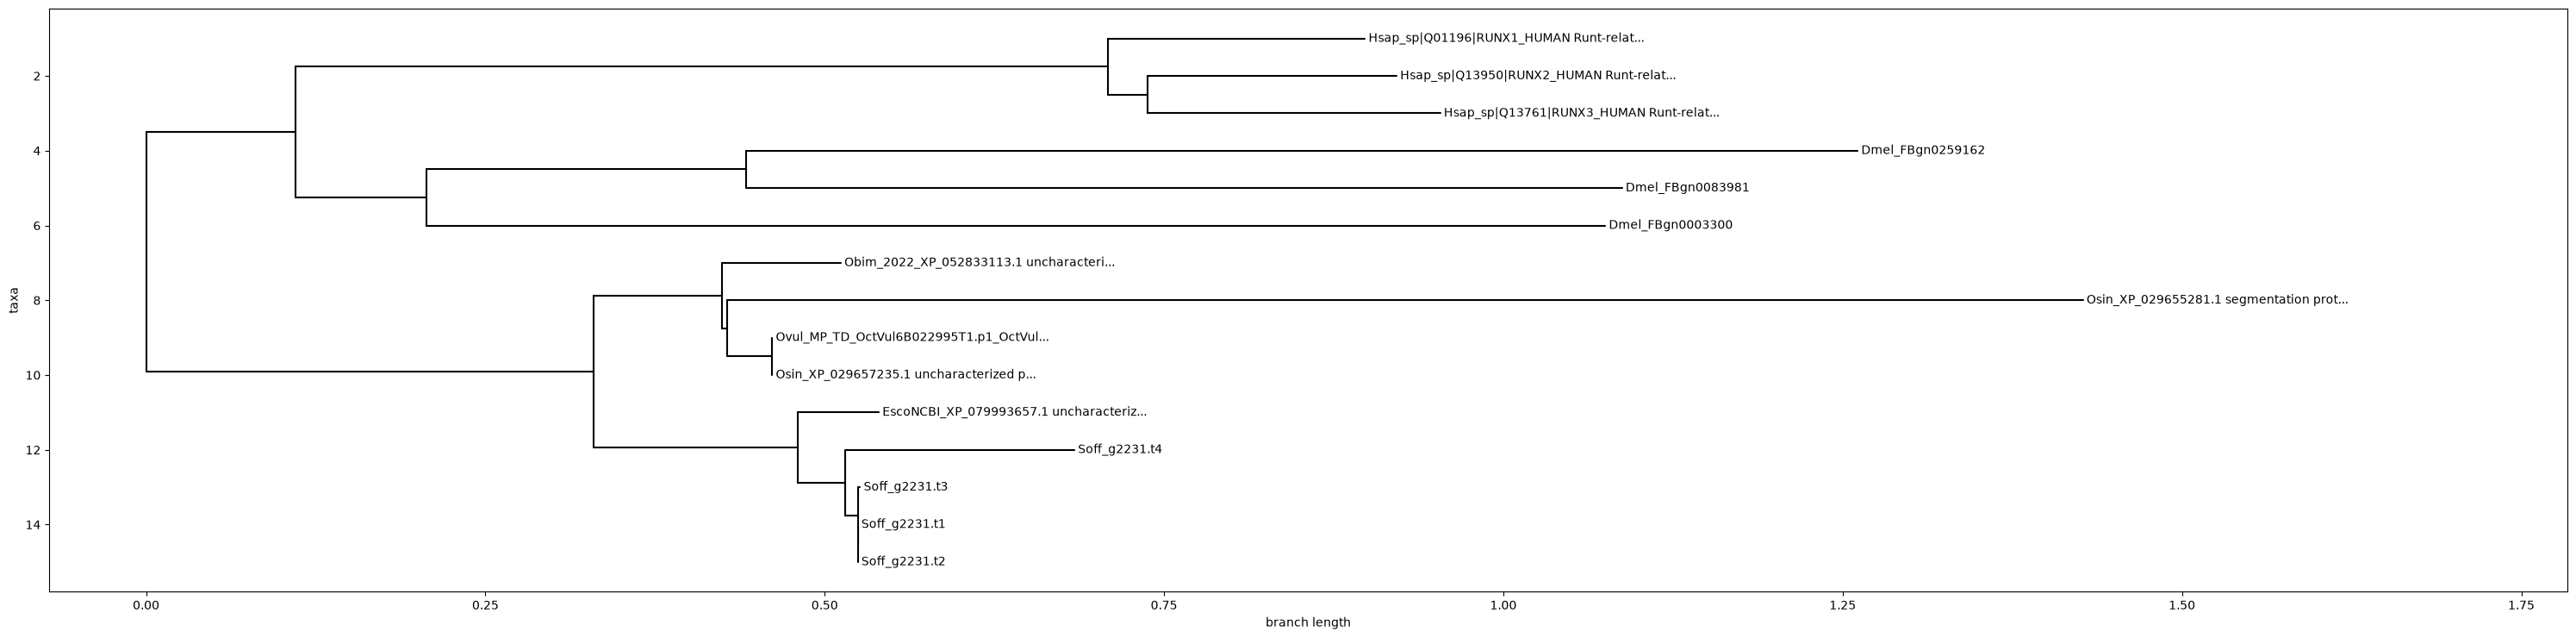

In [26]:
import matplotlib.pyplot as plt
from Bio import Phylo
from io import StringIO

import matplotlib as mpl

mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams["svg.fonttype"] = "none"
mpl.rcParams["font.family"] = "DejaVu Sans"

gene = 'runx'
tree_file = matches_df.loc[12, "tree_file"]

with open(tree_file, "r") as handle:
    newick_text = handle.read().strip()

fixed_newick = quote_newick_tip_labels(newick_text)

tree = Phylo.read(
    StringIO(fixed_newick),
    "newick"
)

# Remove OrthoFinder internal node labels: n0, n1, n2, ...
for clade in tree.get_nonterminals():
    clade.name = None

n_tips = len(tree.get_terminals())

fig, ax = plt.subplots(
    figsize=(30, max(5, n_tips * 0.5))
)

Phylo.draw(
    tree,
    axes=ax,
    do_show=False,
    show_confidence=False
)

plt.tight_layout()
plt.savefig(f'figures/paper/revision/phylogeny/{gene}_tree.svg', bbox_inches='tight')
plt.show()

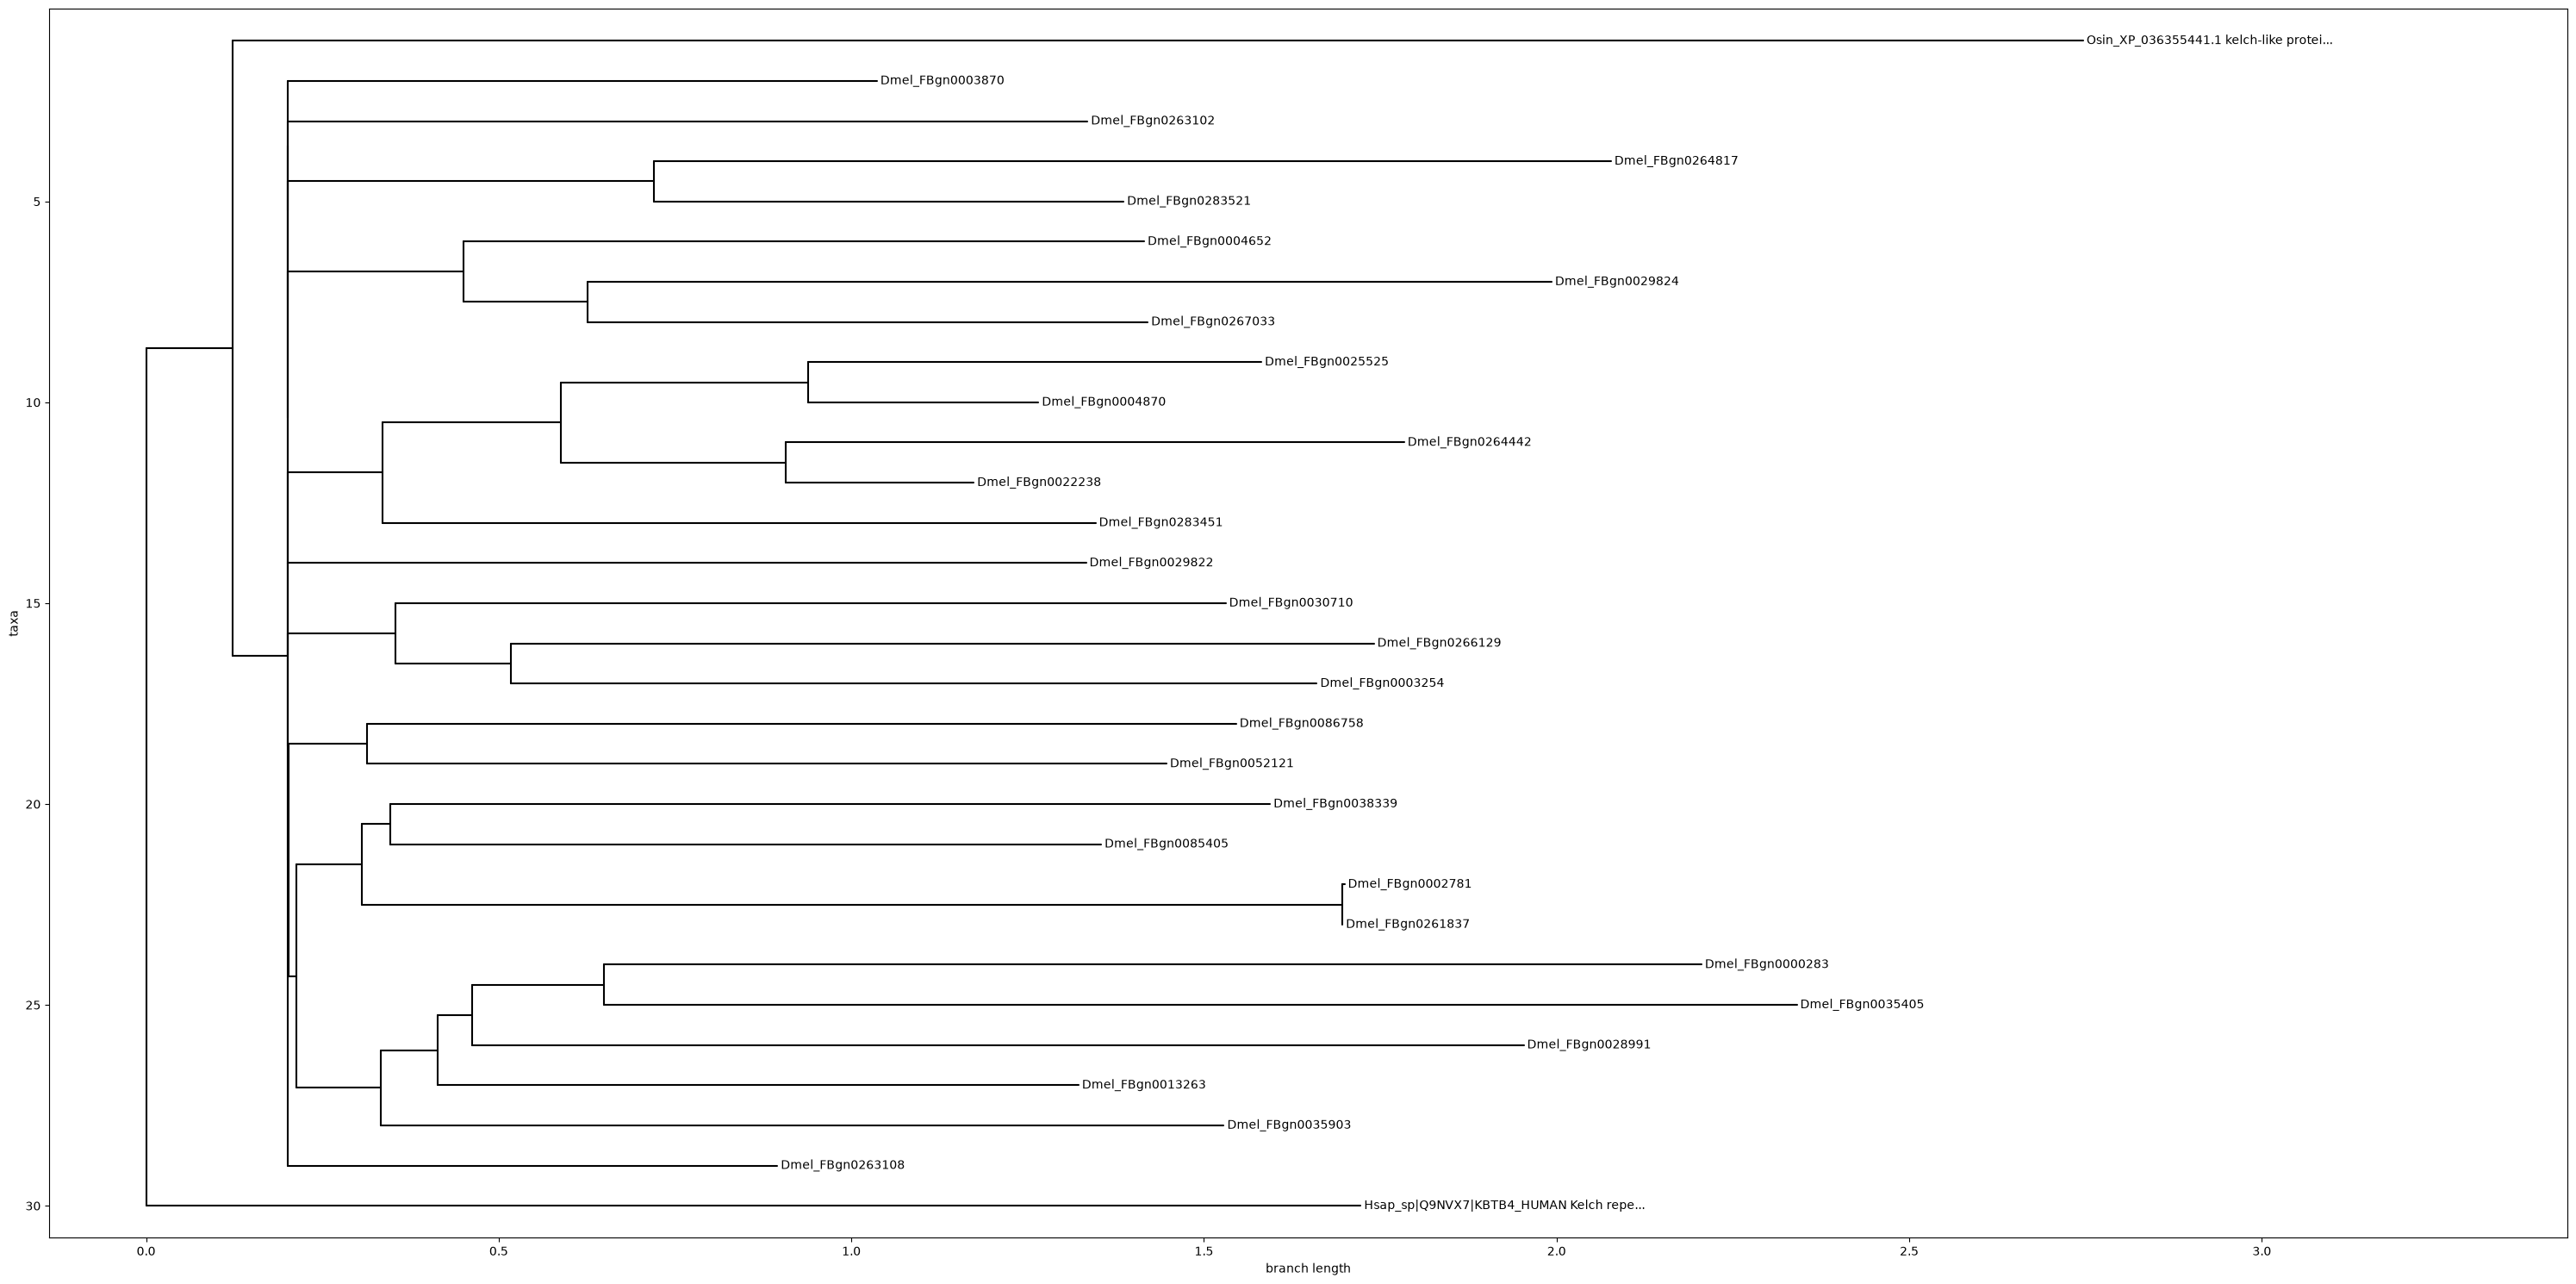

In [27]:
import matplotlib.pyplot as plt
from Bio import Phylo
from io import StringIO

import matplotlib as mpl

mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams["svg.fonttype"] = "none"
mpl.rcParams["font.family"] = "DejaVu Sans"

gene = 'Dm_ttk'
tree_file = matches_df.loc[13, "tree_file"]

with open(tree_file, "r") as handle:
    newick_text = handle.read().strip()

fixed_newick = quote_newick_tip_labels(newick_text)

tree = Phylo.read(
    StringIO(fixed_newick),
    "newick"
)

# Remove OrthoFinder internal node labels: n0, n1, n2, ...
for clade in tree.get_nonterminals():
    clade.name = None

n_tips = len(tree.get_terminals())

fig, ax = plt.subplots(
    figsize=(30, max(5, n_tips * 0.5))
)

Phylo.draw(
    tree,
    axes=ax,
    do_show=False,
    show_confidence=False
)

plt.tight_layout()
plt.savefig(f'figures/paper/revision/phylogeny/{gene}_tree.svg', bbox_inches='tight')
plt.show()

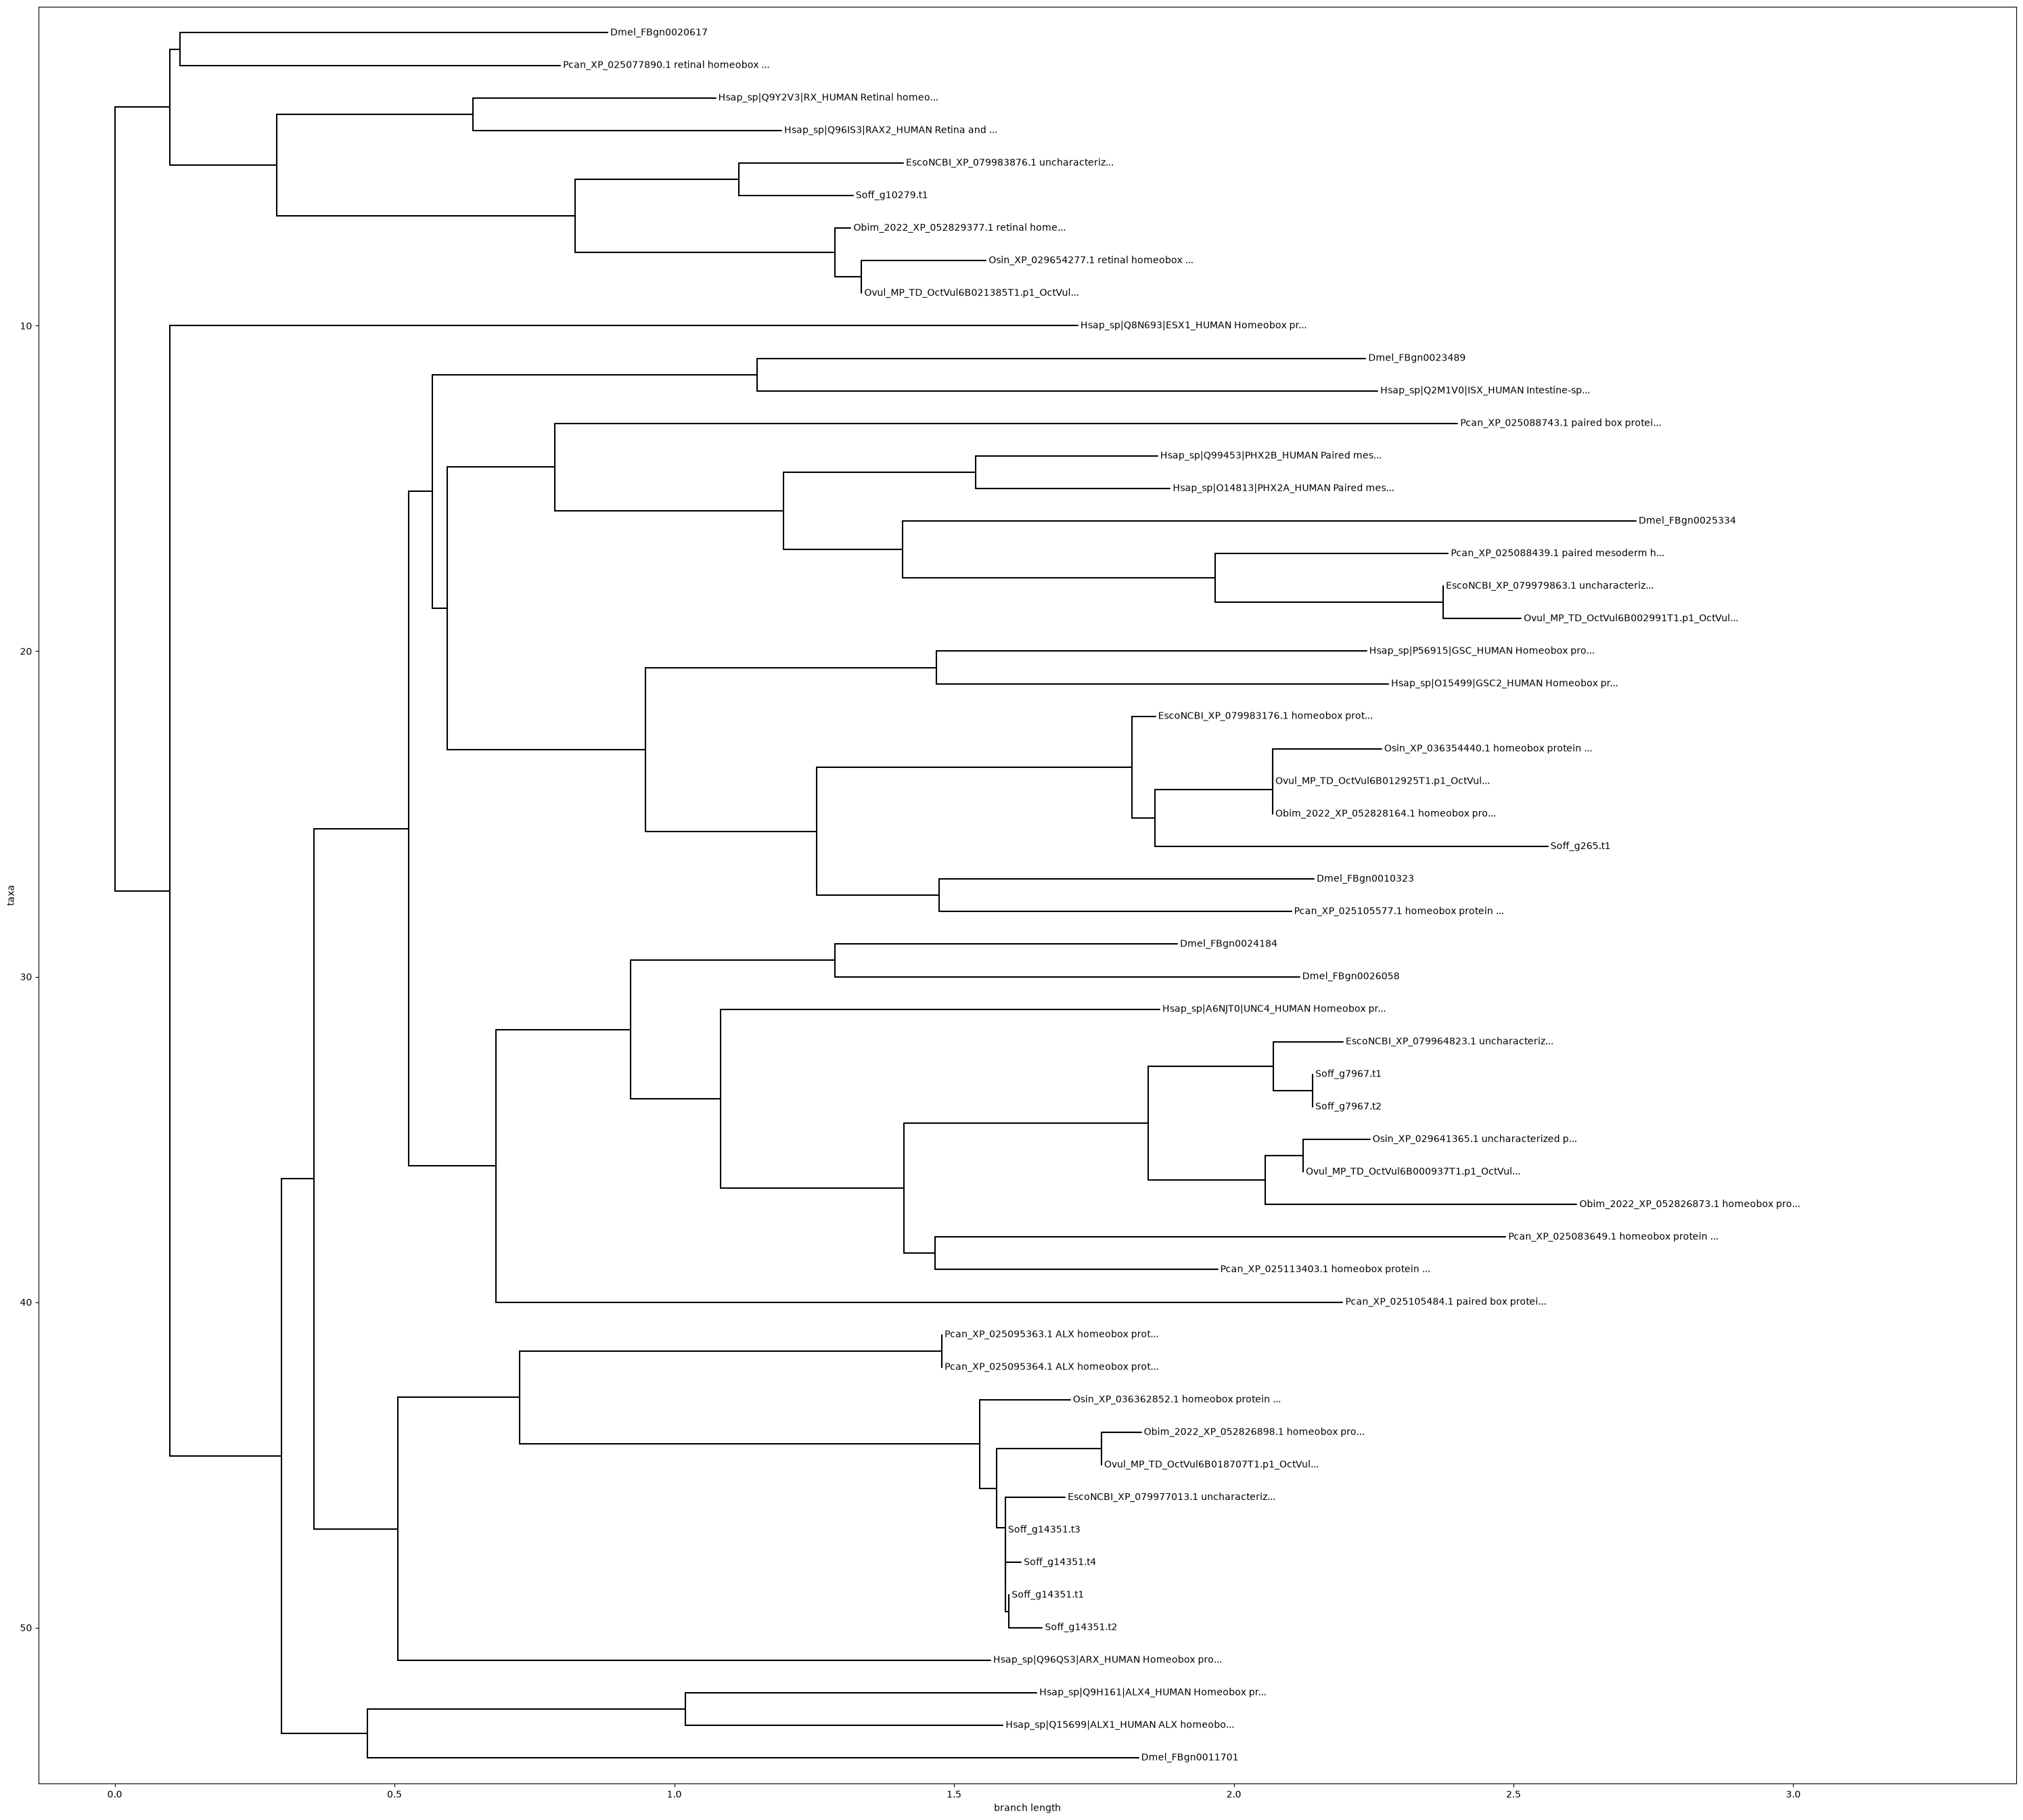

In [28]:
import matplotlib.pyplot as plt
from Bio import Phylo
from io import StringIO

import matplotlib as mpl

mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams["svg.fonttype"] = "none"
mpl.rcParams["font.family"] = "DejaVu Sans"

gene = 'repo'
tree_file = matches_df.loc[14, "tree_file"]

with open(tree_file, "r") as handle:
    newick_text = handle.read().strip()

fixed_newick = quote_newick_tip_labels(newick_text)

tree = Phylo.read(
    StringIO(fixed_newick),
    "newick"
)

# Remove OrthoFinder internal node labels: n0, n1, n2, ...
for clade in tree.get_nonterminals():
    clade.name = None

n_tips = len(tree.get_terminals())

fig, ax = plt.subplots(
    figsize=(30, max(5, n_tips * 0.5))
)

Phylo.draw(
    tree,
    axes=ax,
    do_show=False,
    show_confidence=False
)

plt.tight_layout()
plt.savefig(f'figures/paper/revision/phylogeny/{gene}_tree.svg', bbox_inches='tight')
plt.show()

# species tree

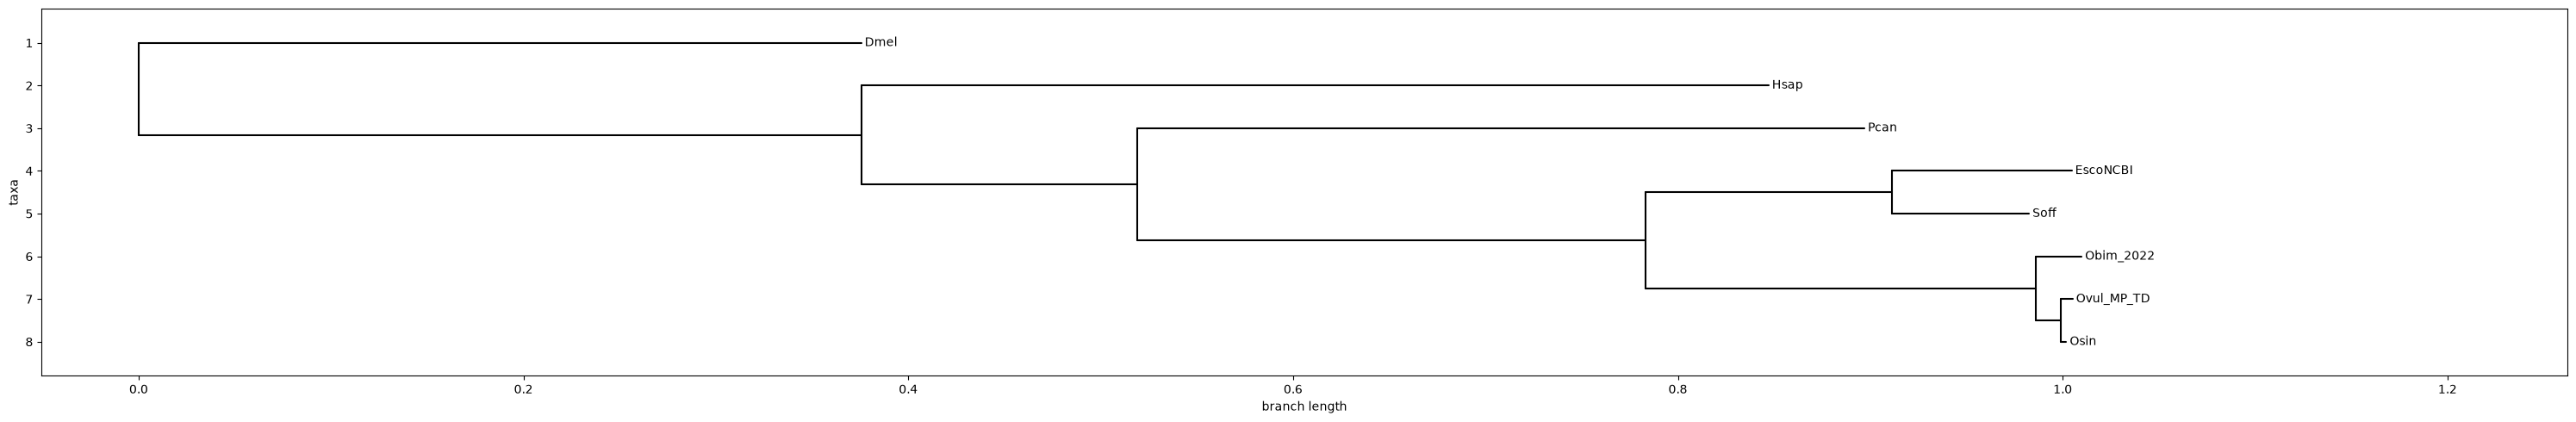

In [30]:
import matplotlib.pyplot as plt
from Bio import Phylo
from io import StringIO

import matplotlib as mpl

mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams["svg.fonttype"] = "none"
mpl.rcParams["font.family"] = "DejaVu Sans"

gene = 'species'

tree_file = (
    '/staging/leuven/stg_00171/Mark/OrthoFinder/2026_07_proteomes/OrthoFinder/Results_Aug04/Species_Tree/SpeciesTree_rooted_node_labels.txt'
)

with open(tree_file, "r") as handle:
    newick_text = handle.read().strip()

fixed_newick = quote_newick_tip_labels(newick_text)

tree = Phylo.read(
    StringIO(fixed_newick),
    "newick"
)

# Remove OrthoFinder internal node labels: n0, n1, n2, ...
for clade in tree.get_nonterminals():
    clade.name = None

n_tips = len(tree.get_terminals())

fig, ax = plt.subplots(
    figsize=(30, max(5, n_tips * 0.5))
)

Phylo.draw(
    tree,
    axes=ax,
    do_show=False,
    show_confidence=False
)

plt.tight_layout()
plt.savefig(f'figures/paper/revision/phylogeny/{gene}_tree.svg', bbox_inches='tight')
plt.show()